*February 11th, 2026*

<img src="https://imgur.com/tObZbvZ.png" height="200">

## **Long-read RNA-seq Analysis ─ Part 3**
*Uncovering gene and transcript-level differential expression*

[**Access this notebook at Google Colab!**](https://colab.research.google.com/drive/178lcLbCPzH-BptseY5hYX7sRT6BqKvMq?usp=sharing)

---

*Vinicius Maracaja-Coutinho* <sup>*,1,2,3</sup> and *Bárbara Borges* <sup>+,1,2</sup>

> <sup>*</sup> Principal Investigator ─ Bioinformatics PhD
>
> <sup>+</sup> Biotechnologist ─ Bioinformatics MSc(c)

<sup>1</sup> *Laboratory of Integrative Bioinformatics (LIB), Unidad de Genómica Avanzada, Universidad de Chile*

<sup>2</sup> *Bioinformatics Multidisciplinary Environment (BioME), UFRN, Brazil*

<sup>3</sup> *Laboratory of Precision Medicine and Health, Fiocruz Salvador, Brazil*


## **Environment Setup**



### **Loading of R packages**

Download and set the R env file.

In [61]:
# download the R environment file, where you could change the environment file you build in the previous steps
R_environment_file <- "https://drive.usercontent.google.com/download?id=1s7NkfXo3mC1hZai-L0bBVDkQ4mQCD6Wa&export=download&authuser=0&confirm=t&uuid=0a876a76-72a5-41f4-8ccf-1bf98d14e5bc&at=APcXIO2D90ENCON4Y6W1OwcpiAE9:1770450565250"
download.file(R_environment_file,
      destfile="./library.tar.gz")

# unzip the compressed R library file: 'library.tar.gz' into the R library folder
untar("library.tar.gz", "library")

# change the R library directory into './library'
.libPaths("library")

**Required packages**

This cell loads plotting and Bioconductor packages used across the tutorial. Ensure `DESeq2`, `apeglm`, and `biomaRt` are installed from Bioconductor prior to running. `tidyverse` is used for data wrangling and `pheatmap` for heatmaps.

In [62]:
library(cowplot)
library(RColorBrewer)
library(viridis)
library(ggrepel)
library(pheatmap)
library(biomaRt)
library(DESeq2)
library(ggbio)
library(apeglm)
library(httr)
library(tidyverse)
library(scales)
library(ggplot2)
library(matrixStats)

## **Dataset**

### Non-small cell lung cancer

During Part 2, we saw the assembly and quantification of the Non-small cell lung cancer transcriptomes for the HCC827 and NCI-H1975 cell lines (BioProject PRJNA723287). Now, we are going to retrieve the **gene and full-length transcript counts** in order to perform differential expression analysis. To simplify analysis, only reference genes and transcripts will be used.

**Data sources and format**
We fetch pre-prepared count matrices (genes and full-length transcripts). Each file is a tab-separated table with one feature per row and samples as columns. Counts must be raw integers (no prior normalization). The next cells will read these into R.

Download the files count matrix files

In [63]:
# Download the matrices
download.file("https://raw.githubusercontent.com/integrativebioinformatics/EBI-lrRNAseq-2026/refs/heads/main/data/matrices/ref_gene_counts.tsv", destfile = "ref_gene_counts.tsv")
download.file("https://raw.githubusercontent.com/integrativebioinformatics/EBI-lrRNAseq-2026/refs/heads/main/data/matrices/ref_tx_full_length_counts.tsv", destfile = "ref_tx_full_length_counts.tsv")

Download the sample metadata table

In [64]:
download.file("https://raw.githubusercontent.com/integrativebioinformatics/EBI-lrRNAseq-2026/refs/heads/main/data/matrices/sample_info.csv", destfile = "sample_info.csv")

In [65]:
gene_counts <- read.table("ref_gene_counts.tsv", header = TRUE)
transcript_counts <- read.table("ref_tx_full_length_counts.tsv", header = TRUE)

**Raw counts for reference genes**

In [66]:
head(gene_counts)

,GENEID,R1_H1975,R2_H1975,R3_H1975,R1_HCC827,R2_HCC827,R3_HCC827
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000000003,2044.00000,1943,1863.00000,3619.00000,2459.00001,3796.99999
2,ENSG00000000005,0.00000,0,0.00000,0.00000,0.00000,1.00000
3,ENSG00000000419,4079.00000,2845,3477.00000,1647.00000,1044.00001,1643.00000
4,ENSG00000000457,418.99999,289,363.00001,76.99999,54.00001,269.99999
5,ENSG00000000460,78.99999,56,61.00002,369.00000,253.00000,96.99999
6,ENSG00000000938,1.00000,1,4.00000,0.00000,4.00000,0.00000


**Raw counts for reference transcripts**

In [67]:
head(transcript_counts)

,TXNAME,R1_H1975,R2_H1975,R3_H1975,R1_HCC827,R2_HCC827,R3_HCC827
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENST00000000233,5674.0000,6245.00000,4945.0000,3943.0000,3482.0000,4046.00000
2,ENST00000000412,849.0000,779.00000,745.0000,736.0000,355.0000,752.00000
3,ENST00000000442,0.0000,0.22534,0.0000,0.0000,0.0000,0.55645
4,ENST00000001008,546.0000,716.00000,483.0000,999.0000,807.0000,1309.00000
5,ENST00000002125,140.0000,136.00000,105.0000,70.0000,36.0000,96.00000
6,ENST00000002165,924.4368,1306.97240,845.3776,823.3936,423.3404,817.23085


**Annotation querying step (biomaRt)**
We query Ensembl via `biomaRt` to map Ensembl IDs to human-readable gene/transcript names. This helps when labeling plots and writing result tables. Network connections to Ensembl may be rate-limited; consider caching the mapping for repeated runs.

Extract the gene IDs to search their gene symbols through biomaRt.

In [68]:
# Extract ids

g_ids <- list(gene_counts$GENEID)

# Connect to ensembl

# apply biomaRt to gather metadata

ensembl <- useEnsembl(biomart="genes",
                      dataset="hsapiens_gene_ensembl",
                      version=115)

g_attributes <- c("ensembl_gene_id",
                "external_gene_name")

g_filter <- "ensembl_gene_id"

ens_genes <- getBM(attributes=g_attributes, filters=g_filter, values=g_ids,
                   mart=ensembl)

# exchange empty names for their ID
ens_genes <- ens_genes %>%
  mutate(external_gene_name = ifelse(is.na(external_gene_name) | external_gene_name == "", ensembl_gene_id, external_gene_name)) %>%
  distinct(external_gene_name, .keep_all = TRUE)

# Join the count matrix
gene_counts <- gene_counts %>%
  semi_join(ens_genes, by = c("GENEID" = "ensembl_gene_id")) %>%
  distinct(GENEID, .keep_all = TRUE) %>%
  left_join(ens_genes[, c("ensembl_gene_id", "external_gene_name")],
            by = c("GENEID" = "ensembl_gene_id"))

# Process the annotated matrix to substitute names and remove GENEID column
gene_matrix <- gene_counts %>%
  rename(gene_symbol = external_gene_name) %>%
  dplyr::select(-GENEID) %>%
  dplyr::select(gene_symbol, everything())

head(gene_matrix)

,gene_symbol,R1_H1975,R2_H1975,R3_H1975,R1_HCC827,R2_HCC827,R3_HCC827
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TSPAN6,2044.00000,1943,1863.00000,3619.00000,2459.00001,3796.99999
2,TNMD,0.00000,0,0.00000,0.00000,0.00000,1.00000
3,DPM1,4079.00000,2845,3477.00000,1647.00000,1044.00001,1643.00000
4,SCYL3,418.99999,289,363.00001,76.99999,54.00001,269.99999
5,FIRRM,78.99999,56,61.00002,369.00000,253.00000,96.99999
6,FGR,1.00000,1,4.00000,0.00000,4.00000,0.00000


Now, extract the transcript IDs to search their symbols through biomaRt.

In [69]:
# Extract ids
t_ids <- list(transcript_counts$TXNAME)

# apply biomaRt to gather metadata

t_attributes <- c("ensembl_transcript_id",
                "external_transcript_name")

t_filter <- "ensembl_transcript_id"

ens_tx <- getBM(attributes=t_attributes, filters=t_filter, values=t_ids, mart=ensembl)

# exchange empty names for their ID
ens_tx <- ens_tx %>%
  mutate(external_transcript_name = ifelse(is.na(external_transcript_name) | external_transcript_name == "",
                                                ensembl_transcript_id,
                                                external_transcript_name)) %>%
  distinct(external_transcript_name, .keep_all = TRUE)

# Join the count matrix
transcript_counts <- transcript_counts %>%
  semi_join(ens_tx, by = c("TXNAME" = "ensembl_transcript_id")) %>%
  distinct(TXNAME, .keep_all = TRUE) %>%
  left_join(ens_tx[, c("ensembl_transcript_id", "external_transcript_name")],
            by = c("TXNAME" = "ensembl_transcript_id"))

# Process the annotated matrix to substitute names and remove TXNAME column
transcript_matrix <- transcript_counts %>%
  rename(symbol = external_transcript_name) %>%
  dplyr::select(-TXNAME) %>%
  dplyr::select(symbol, everything())

head(transcript_matrix)

,symbol,R1_H1975,R2_H1975,R3_H1975,R1_HCC827,R2_HCC827,R3_HCC827
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ARF5-201,5674.0000,6245.00000,4945.0000,3943.0000,3482.0000,4046.00000
2,M6PR-201,849.0000,779.00000,745.0000,736.0000,355.0000,752.00000
3,ESRRA-201,0.0000,0.22534,0.0000,0.0000,0.0000,0.55645
4,FKBP4-201,546.0000,716.00000,483.0000,999.0000,807.0000,1309.00000
5,NDUFAF7-201,140.0000,136.00000,105.0000,70.0000,36.0000,96.00000
6,FUCA2-201,924.4368,1306.97240,845.3776,823.3936,423.3404,817.23085


## **Differential Gene Expression**

Now we can start the gene-level differential expression analysis. Let's transform the gene_counts table into a matrix.

**Gene-level workflow (overview)**

This section performs differential gene expression (DGE) following DESeq2 best practices. Steps include:
- Convert annotated counts to a numeric matrix and ensure sample names match metadata.
- Create a `DESeqDataSet` with an appropriate `design` (here `~group`).
- Pre-filter low-count genes to improve dispersion estimates.
- Run `DESeq()` to estimate size factors, dispersions and fit the GLM.
- Use `vst()`/`rlog()` for PCA and heatmaps (visualization only).
- Extract results with `results()` and apply `lfcShrink()` (e.g., `apeglm`) for stable LFCs before ranking or plotting.

Notes: set factor reference levels explicitly in `sample_info` if you need a specific baseline for comparisons.

In [70]:
rownames(gene_matrix) <- gene_matrix[[1]]
gene_matrix[[1]] <- NULL
gene_matrix <- as.matrix(gene_matrix)
head(gene_matrix)

,R1_H1975,R2_H1975,R3_H1975,R1_HCC827,R2_HCC827,R3_HCC827
TSPAN6,2044.00000,1943,1863.00000,3619.00000,2459.00001,3796.99999
TNMD,0.00000,0,0.00000,0.00000,0.00000,1.00000
DPM1,4079.00000,2845,3477.00000,1647.00000,1044.00001,1643.00000
SCYL3,418.99999,289,363.00001,76.99999,54.00001,269.99999
FIRRM,78.99999,56,61.00002,369.00000,253.00000,96.99999
FGR,1.00000,1,4.00000,0.00000,4.00000,0.00000


In [71]:
sample_info <- read.csv("sample_info.csv", row.names = 1)
# Convert the 'group' column intoto a factor
sample_info$group <- as.factor(sample_info$group)

# Validate that the sample info metadata matches the samples on the matrix
all(rownames(sample_info) == colnames(gene_matrix))

[1] TRUE

Take a look on the sample meta_data

In [72]:
sample_info

,group
,<fct>
R1_H1975,H1975
R2_H1975,H1975
R3_H1975,H1975
R1_HCC827,HCC827
R2_HCC827,HCC827
R3_HCC827,HCC827


#### The dds object (DESeqDataSetFromMatrix)

**DESeqDataSet construction**

Here we create the `DESeqDataSet` object which bundles counts and metadata and stores the experimental design. Set factor reference levels explicitly in `sample_info` if you need a specific baseline for contrasts. `round()` ensures integer counts when inputs are numeric.

In [73]:
# Create the DESeqDataSet
dds <- DESeqDataSetFromMatrix(
  countData = round(gene_matrix),
  colData = sample_info,
  design = ~group # Use 'group' as your design variable
)

dds

converting counts to integer mode



class: DESeqDataSet 
dim: 44693 6 
metadata(1): version
assays(1): counts
rownames(44693): TSPAN6 TNMD ... ENSG00000310592 ENSG00000310593
rowData names(0):
colnames(6): R1_H1975 R2_H1975 ... R2_HCC827 R3_HCC827
colData names(1): group

**Filtering & running DESeq**

We pre-filter features with low counts to improve dispersion estimates and speed. The `DESeq()` call then runs size-factor estimation, dispersion estimation and model fitting. If you have a vert large dataset, expect this step to take a bit longer.

In [74]:
smallestGroupSize <- 3
keep <- rowSums(counts(dds) >= 10) >= smallestGroupSize
dds <- dds[keep,]

dds <- DESeq(dds)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [75]:
summary(dds)

[1] "DESeqDataSet object of length 19639 with 22 metadata columns"

Cell line H1975 was set as the reference level, and HCC827 will be compared to it.

In [76]:
resultsNames(dds)

[1] "Intercept"             "group_HCC827_vs_H1975"

#### VST and PCA

**Transformations for visualization**

Use `vst()` or `rlog()` to stabilize variance across counts before PCA or clustering. These transforms are for visualization and do not affect the statistical testing which uses raw counts.
What is VST

**Variance Stabilizing Transformation (VST)** is a transformation in DESeq2 that removes the mean–variance dependence of count data so that transformed values have approximately constant variance across the dynamic range. Key points:

- Produces a homoscedastic scale suitable for PCA, clustering, heatmaps and distance calculations.  
- Borrows information across features to stabilize low-count variability (more robust than simple log(x+1)).  
- Faster and more scalable than rlog for large datasets; rlog can be more aggressive for small datasets.  
- Intended only for visualization and exploratory analyses — do not use transformed counts for DESeq2’s statistical tests (which use raw counts).

**Principal Component Analysis (PCA)**

**PCA** is a dimensionality reduction technique that transforms the data into a new coordinate system, where the greatest variance by any projection lies on the first coordinate (called principal component), the second greatest variance on the second coordinate, and so on. This is particularly useful for visualizing high-dimensional data and the overall effect of experimental covariates and batch effects.

using ntop=1500 top features by variance



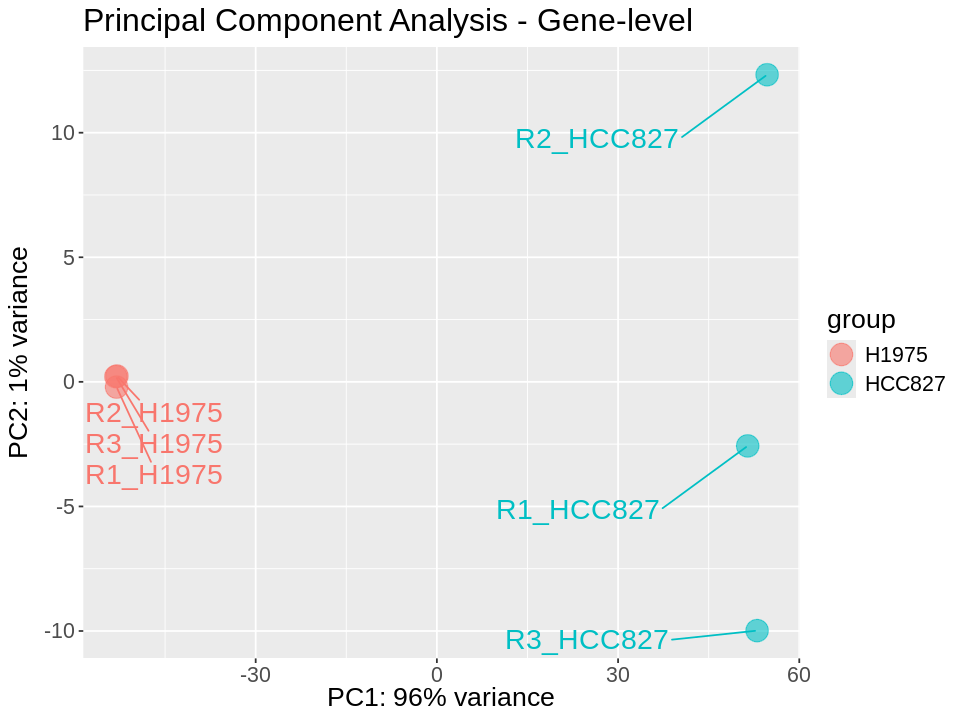

In [77]:
options(repr.plot.width = 8, repr.plot.height = 6)

vsd <- vst(dds, blind=TRUE)
pca_data <- plotPCA(vsd, intgroup="group", returnData=TRUE, ntop=1500) # increase number of top variable genes to 1500
percentVar <- round(100 * attr(pca_data, "percentVar"))

ggplot(pca_data, aes(PC1, PC2, color=group)) +
  geom_point(size=6, alpha=0.6) +
  geom_text_repel(aes(label=as.character(name)),
                  hjust=1.5, vjust=4, size=6,
                  show.legend = FALSE) +
  xlab(paste0("PC1: ",percentVar[1],"% variance")) +
  ylab(paste0("PC2: ",percentVar[2],"% variance")) +
  labs(title = "Principal Component Analysis - Gene-level")+
  theme(text=element_text(size=16))

**Sample distance matrix**

Another use of the VST data is sample clustering. Here, we apply the dist function to the transpose of the transformed count matrix to get sample-to-sample distances. These distance matrices can be visualized using heatmaps, hierarchical clustering, or multidimensional scaling (MDS) to explore the relationships between samples.

Sample distance matrices are used to quantify the dissimilarity between samples based on their expression profiles. In the context of RNA-seq data analysis, these matrices can help identify clusters of similar samples, visualize relationships between samples, and inform downstream analyses such as differential expression testing.

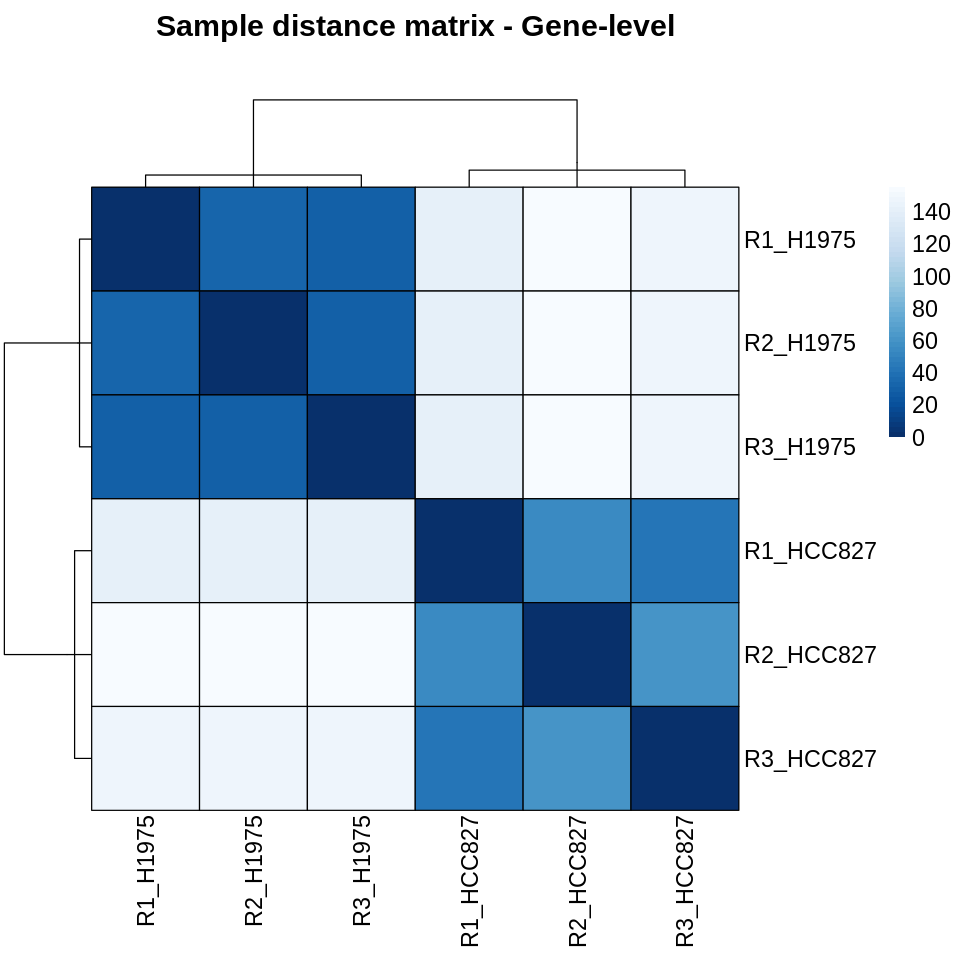

In [78]:
options(repr.plot.width = 8, repr.plot.height = 8)

sampleDists <- dist(t(assay(vsd)))

# Define the desired order
sample_order <- c("R1_HCC827", "R2_HCC827", "R3_HCC827",
                  "R1_H1975", "R2_H1975", "R3_H1975")

ordering_callback <- function(hc, mat) {
  hc$labels <- sample_order
  hc$order <- order(match(hc$labels, sample_order))
  return(hc)
}

sampleDistMatrix <- as.matrix(sampleDists)
colors <- colorRampPalette(rev(brewer.pal(9, "Blues")))(50)

pheatmap(sampleDistMatrix,
                    color=colors,
                    border_color="black",
                    main="Sample distance matrix - Gene-level\n",
                    clustering_callback=ordering_callback,
                    fontsize=14, fontsize_row=14, fontsize_col=14, angle_col=90)

#### Significance Analysis

**Extracting results**

`results()` returns log2 fold changes, p-values and adjusted p-values. DESeq2  performs independent filtering based on the mean of normalized counts for each gene, optimizing the number of genes which will have an adjusted p value below a given FDR cutoff, `alpha`.

In [79]:
res05 <- results(dds, alpha=0.05)

summary(res05)


out of 19639 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 6067, 31%
LFC < 0 (down)     : 6188, 32%
outliers [1]       : 12, 0.061%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



Order by LogFoldChange

In [80]:
res05[order(res05$log2FoldChange),]

log2 fold change (MLE): group HCC827 vs H1975 
Wald test p-value: group HCC827 vs H1975 
DataFrame with 19639 rows and 6 columns
           baseMean log2FoldChange     lfcSE      stat       pvalue
          <numeric>      <numeric> <numeric> <numeric>    <numeric>
SNRPN      3355.671       -13.9483   1.18623  -11.7585  6.38226e-32
CT45A3     1192.721       -13.4179   1.18725  -11.3016  1.28807e-29
CT45A9      972.784       -13.1238   1.18732  -11.0533  2.11320e-28
CT45A8      926.373       -13.0532   1.18766  -10.9907  4.23646e-28
CT45A2      914.519       -13.0347   1.18783  -10.9735  5.12234e-28
...             ...            ...       ...       ...          ...
CEACAM5     513.232        12.7123  1.197433   10.6163  2.50399e-26
HOTAIRM1    572.277        12.8700  1.189585   10.8189  2.80058e-27
BEX3       8309.457        13.2879  0.609944   21.7854 3.18840e-105
LINC01980   796.945        13.3479  1.190572   11.2114  3.58654e-29
SFTA2     18108.819        13.4164  0.453134   29.6080 

Order by adjusted p-value

In [81]:
res05[order(res05$padj),]

log2 fold change (MLE): group HCC827 vs H1975 
Wald test p-value: group HCC827 vs H1975 
DataFrame with 19639 rows and 6 columns
                 baseMean log2FoldChange     lfcSE      stat      pvalue
                <numeric>      <numeric> <numeric> <numeric>   <numeric>
PLAAT4           26378.64        5.41133  0.134860   40.1257  0.0000e+00
LCN2             45347.09        8.91397  0.212581   41.9321  0.0000e+00
PDZK1IP1         10849.67        8.02773  0.191868   41.8398  0.0000e+00
CRIP1            12840.98       -7.93504  0.160900  -49.3168  0.0000e+00
VAMP5             2910.48        6.26951  0.163282   38.3969 1.4822e-322
...                   ...            ...       ...       ...         ...
ENSG00000259353  264.6469     -11.245701   2.62626 -4.282013          NA
ENSG00000283782  737.7362      -8.669677   2.14488 -4.042029          NA
ENSG00000286185  183.8567       0.663215   1.88967  0.350969          NA
ENSG00000286964  120.1769      -5.747670   1.60003 -3.592227        

Subset by ordered and adjusted p-value

In [82]:
subset(res05[order(res05$padj),], padj < 0.05)

log2 fold change (MLE): group HCC827 vs H1975 
Wald test p-value: group HCC827 vs H1975 
DataFrame with 12255 rows and 6 columns
                 baseMean log2FoldChange     lfcSE      stat      pvalue
                <numeric>      <numeric> <numeric> <numeric>   <numeric>
PLAAT4           26378.64        5.41133  0.134860   40.1257  0.0000e+00
LCN2             45347.09        8.91397  0.212581   41.9321  0.0000e+00
PDZK1IP1         10849.67        8.02773  0.191868   41.8398  0.0000e+00
CRIP1            12840.98       -7.93504  0.160900  -49.3168  0.0000e+00
VAMP5             2910.48        6.26951  0.163282   38.3969 1.4822e-322
...                   ...            ...       ...       ...         ...
PRR4              66.6174      -0.783997  0.363550  -2.15650   0.0310445
ENSG00000308785   10.2958       1.915716  0.888579   2.15593   0.0310891
ENSG00000297778   12.0982       1.569017  0.728148   2.15481   0.0311771
ENSG00000310242   12.9869      -1.449333  0.672676  -2.15458   0.031

#### Shrinkage

**Log fold-change shrinkage**

Shrinkage (e.g., `apeglm`) stabilizes large LFC estimates for low-count genes and improves ranking for downstream interpretation and plotting (MA/volcano). Use shrunk LFCs for visualization and ranking.

Shrinkage of effect size (LFC estimates) is useful for visualization and ranking of genes. To shrink the LFC, we pass the `dds` object to the function `lfcShrink`.

In [83]:
reslfc <- lfcShrink(dds, coef = 2, type = "apeglm")

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



In [84]:
reslfc

log2 fold change (MAP): group HCC827 vs H1975 
Wald test p-value: group HCC827 vs H1975 
DataFrame with 19639 rows and 5 columns
                 baseMean log2FoldChange     lfcSE      pvalue        padj
                <numeric>      <numeric> <numeric>   <numeric>   <numeric>
TSPAN6           2765.359       1.247522  0.188313 1.56573e-11 9.78370e-11
DPM1             2289.605      -0.724632  0.200107 2.24880e-04 5.38521e-04
SCYL3             230.975      -0.552447  0.654019 2.77337e-01 3.46861e-01
FIRRM             163.395       2.262891  0.351693 2.17864e-11 1.34848e-10
CFH               258.559      -1.343317  0.200784 8.67624e-12 5.60528e-11
...                   ...            ...       ...         ...         ...
ENSG00000310537   90.6812       1.036508  0.261797 4.10497e-05 1.11544e-04
ENSG00000310547    6.7573      -6.079409  2.613872 2.05875e-05 5.87654e-05
PAXX            2304.3442       1.002114  0.188693 6.34338e-08 2.55074e-07
ENSG00000310566  216.3319       0.100182  0.73

In [85]:
summary(reslfc)


out of 19639 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 6540, 33%
LFC < 0 (down)     : 6749, 34%
outliers [1]       : 12, 0.061%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [87]:
# Convert reslfc to a data frame
reslfc_df <- as.data.frame(reslfc)
reslfc_df <- tibble::rownames_to_column(reslfc_df, var = "gene_symbol")

# Handling NA values
reslfc_df <- na.omit(reslfc_df)

write.csv(reslfc_df, file="reslfc_df_dge.csv")

**MA Plot**
In DESeq2, the function `plotMA` shows the log2 fold changes attributable to a given variable over the mean of normalized counts for all the samples in the DESeqDataSet. Points will be colored blue if the adjusted p-value is less than 0.1. Points which fall out of the window are plotted as open triangles pointing either up or down.

> It is more useful to visualize the MA-plot for the shrunken log2 fold changes, which remove the noise associated with log2 fold changes from low count genes without requiring arbitrary filtering thresholds.

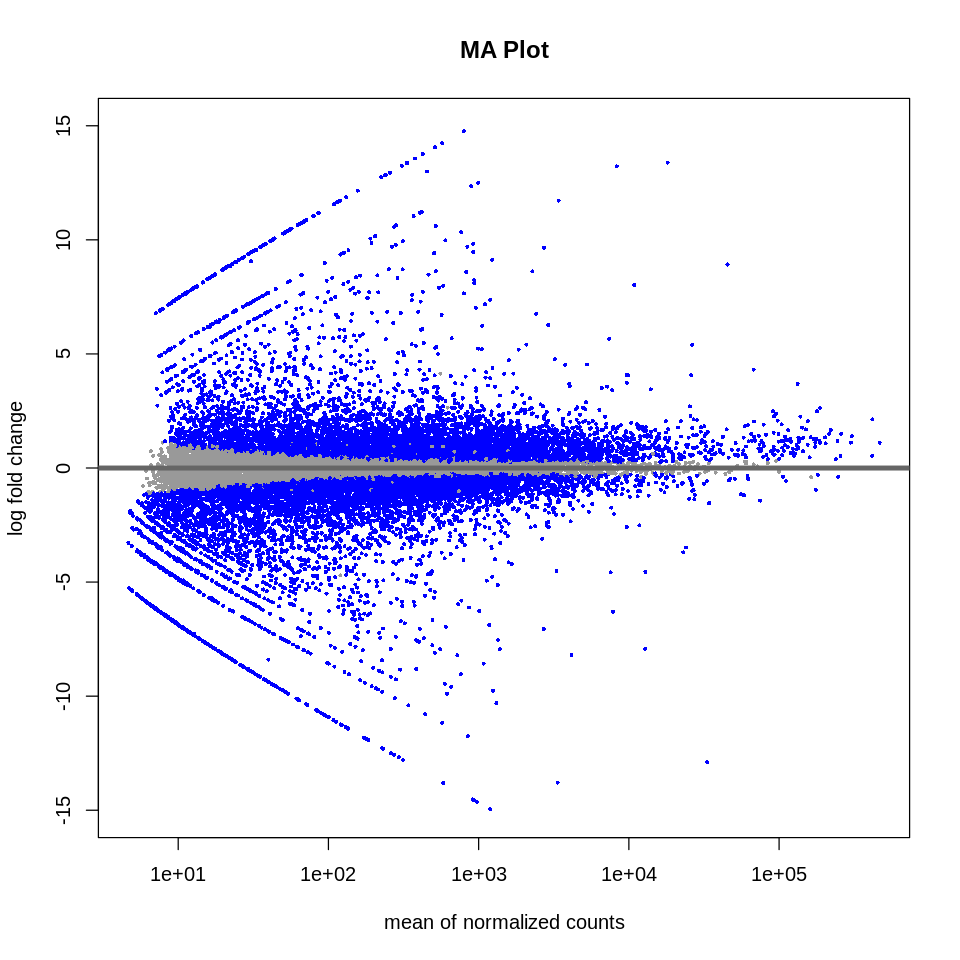

In [88]:
# Create MA Plot

plotMA(reslfc, main="MA Plot", ylim=c(-15,15))

Filter for the adjusted p-value

In [86]:
res05lfc <- subset(reslfc, padj < 0.05)

summary(res05lfc)


out of 12255 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 6067, 50%
LFC < 0 (down)     : 6188, 50%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



#### Visualizing Gene-level Differential Expression

**Volcano plot**

Volcano plots display effect size (log2FC) against statistical significance (-log10 padj). Define thresholds for fold change and padj to highlight biologically meaningful genes. Use shrunken LFCs to avoid emphasizing noisy large estimates.

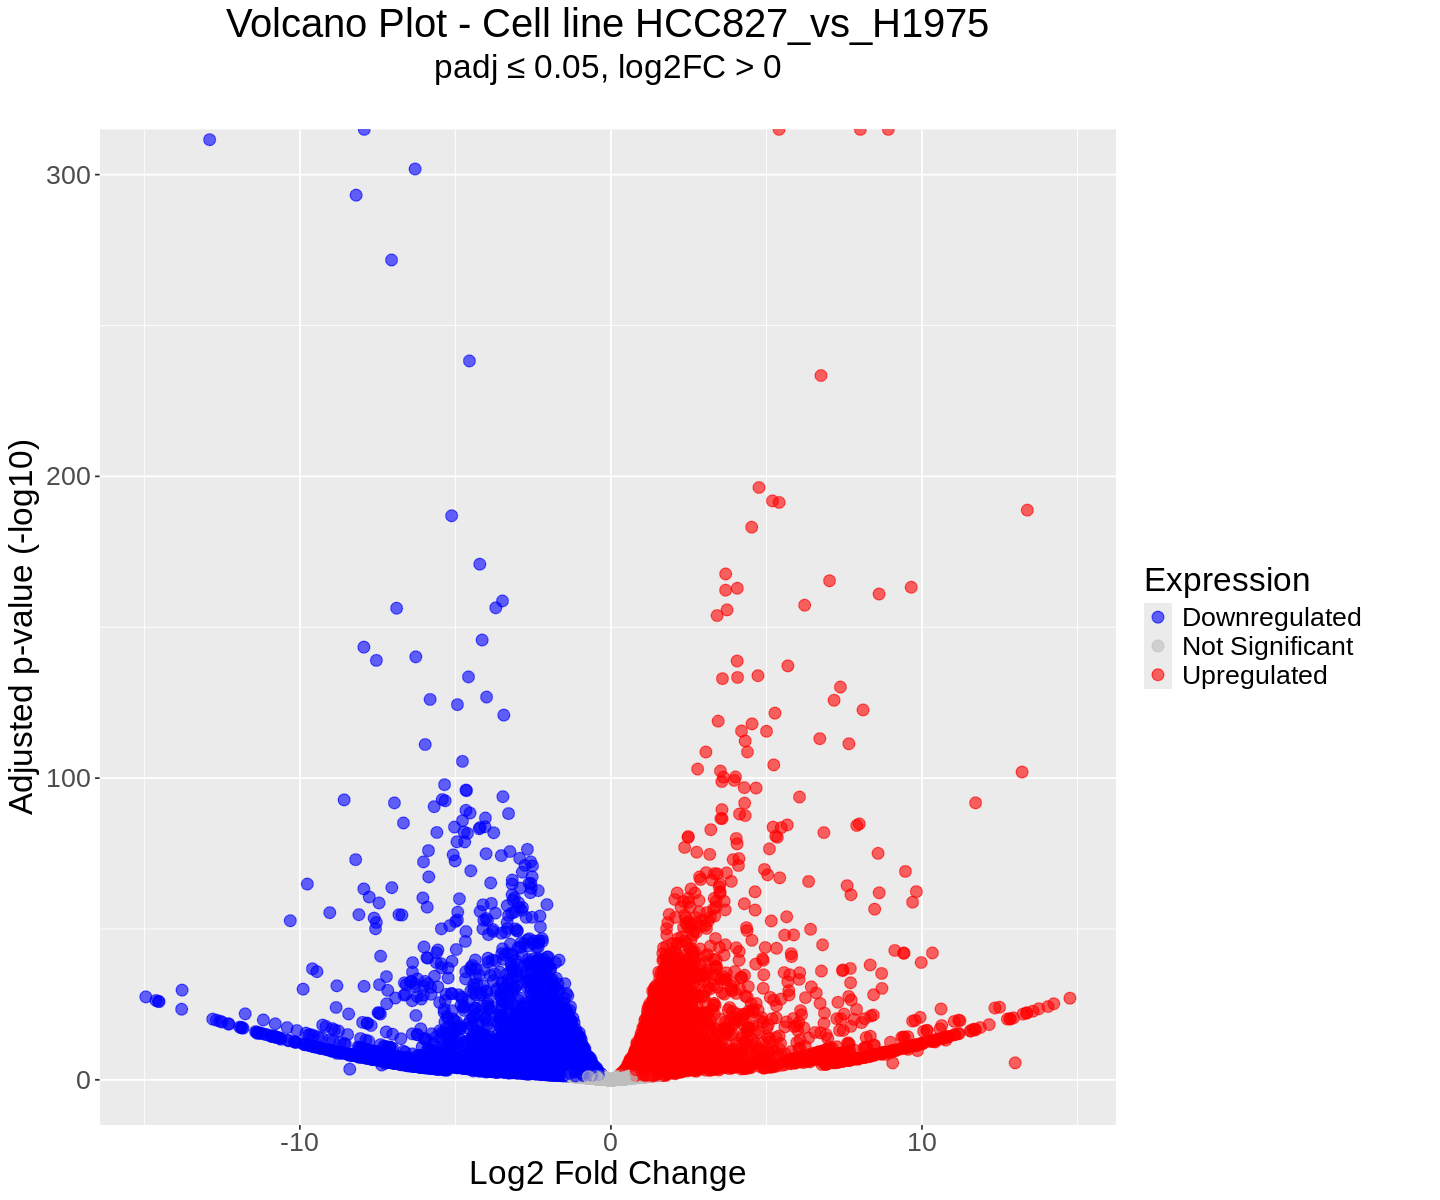

In [89]:
options(repr.plot.width = 12, repr.plot.height = 10)

# Define significance and log2 fold change thresholds
sigThreshold <- 0.05
lfcThreshold <- 0 # Adjust this threshold as needed

# Adding a column for coloring based on significance and fold change
reslfc_df$exp <- with(reslfc_df, ifelse(padj < sigThreshold & log2FoldChange >= lfcThreshold, "Upregulated", ifelse(padj < sigThreshold & log2FoldChange <= -lfcThreshold, "Downregulated", "Not Significant")))

reslfc_df_sig <- reslfc_df %>%
  filter(exp %in% c("Upregulated", "Downregulated")) %>%
  arrange(padj, -abs(log2FoldChange))

# Adjust point size based on significance
reslfc_df$size <- with(reslfc_df, ifelse(padj < sigThreshold & abs(log2FoldChange) >= lfcThreshold, 3,3))

write.csv(reslfc_df_sig, file="reslfc_df_sig_dge.csv")

# Creating a Volcano Plot with conditional coloring and point sizes
volc <- ggplot(reslfc_df, aes(x = log2FoldChange, y = -log10(padj), color = exp,
                               size = size)) +
  geom_point(alpha = 0.6, size = 3) +
  scale_color_manual(values = c("Upregulated" = "red", "Downregulated" = "blue",
                                "Not Significant" = "grey")) +
  scale_size_identity() +
  labs(x = "Log2 Fold Change", y = "Adjusted p-value (-log10)",
       title = "Volcano Plot - Cell line HCC827_vs_H1975",
       subtitle = "padj ≤ 0.05, log2FC > 0\n") +
  guides(color = guide_legend(title = "Expression")) +
  coord_cartesian(ylim = c(0, 300)) +
  theme(
    legend.position = "right",
    text = element_text(size=20),
    plot.title = element_text(hjust = 0.5),
    plot.subtitle = element_text(hjust = 0.5)
  )

volc

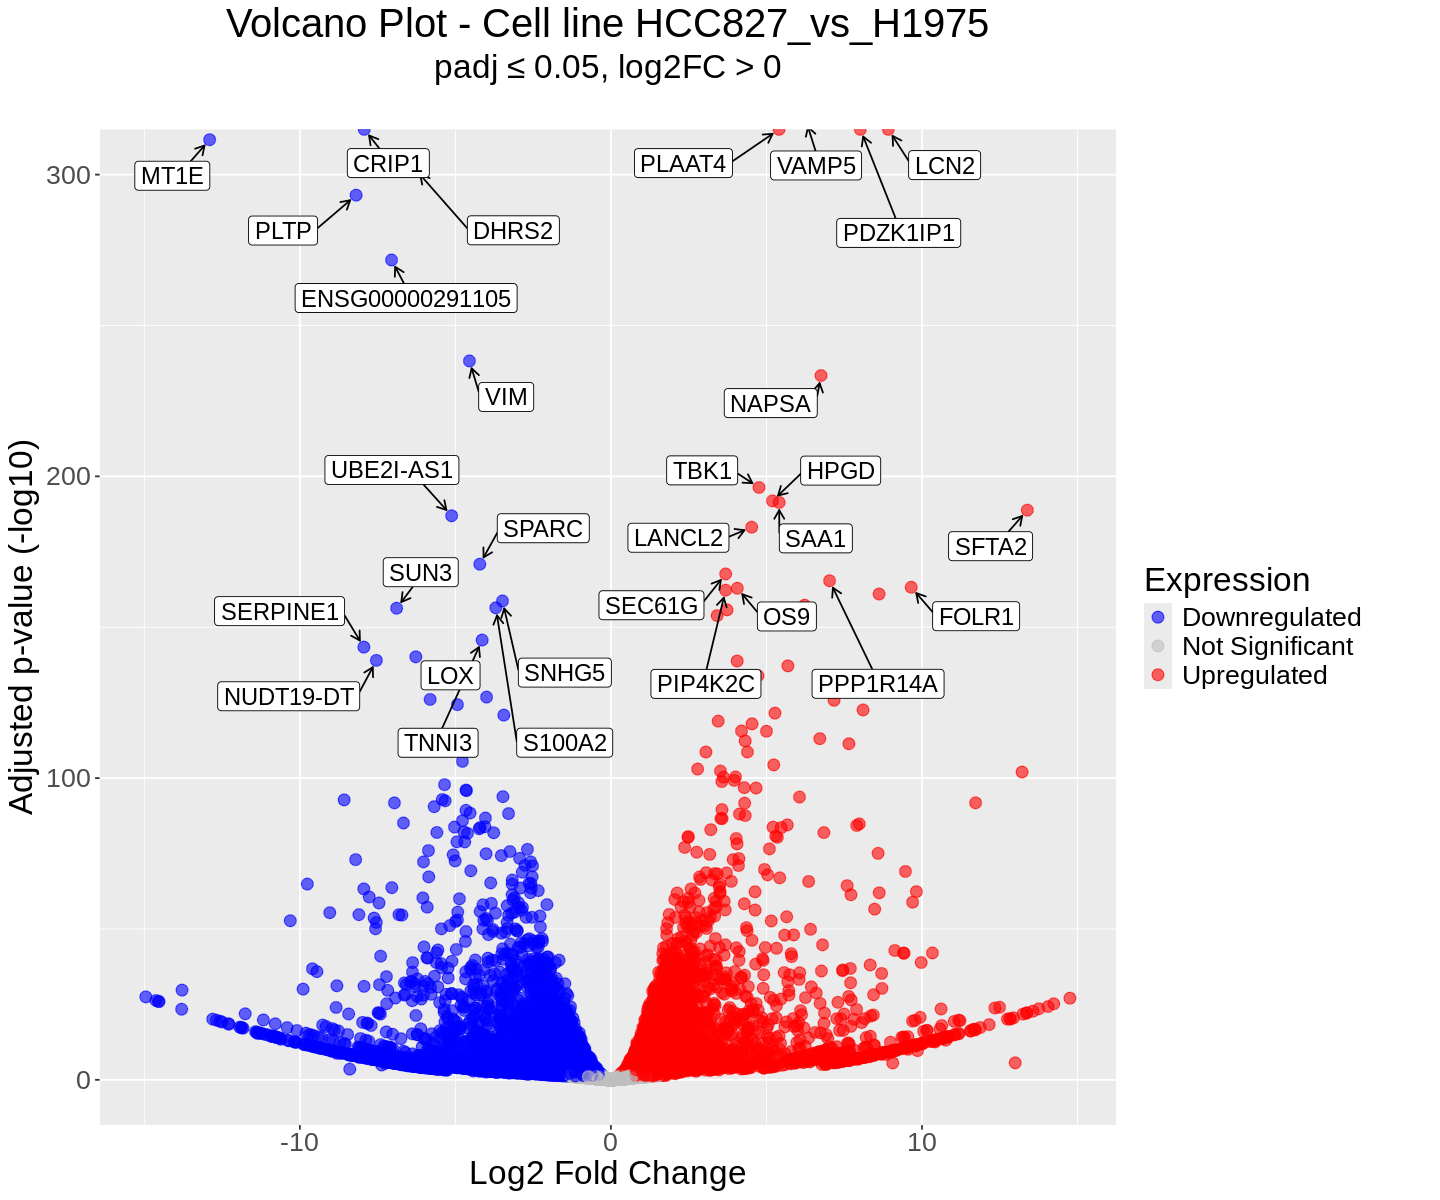

In [90]:
# --- Determine the top N most prominent genes to label ---
top_n <- 15

top_genes_up <- reslfc_df_sig %>%
  filter(exp == "Upregulated") %>%
  arrange(padj, -abs(log2FoldChange)) %>%
  head(top_n)

top_genes_down <- reslfc_df_sig %>%
  filter(exp == "Downregulated") %>%
  arrange(padj, -abs(log2FoldChange)) %>%
  head(top_n)

top_genes <- bind_rows(top_genes_up, top_genes_down)

write.csv(top_genes_up, file="top_15_DGE_up.csv")
write.csv(top_genes_down, file="top_15_DGE_down.csv")

# --- Add labels to the Volcano Plot using ggrepel ---
volc_names <- volc +
  geom_label_repel(
    data = top_genes,
    aes(label = gene_symbol),
    color = "black", # Set label color to black
    size = 5,
    box.padding = unit(0.8, "lines"),
    point.padding = unit(0.5, "lines"),
    segment.color = 'black',
    segment.size = 0.5,
    arrow = arrow(length = unit(0.01, "npc")),
    max.overlaps = Inf
  )

volc_names

**Pheatmap**

To explore a count matrix, it is often instructive to look at it as a heatmap. We can use the VST count matrix to visualize DE genes and their quantification patterns across samples.

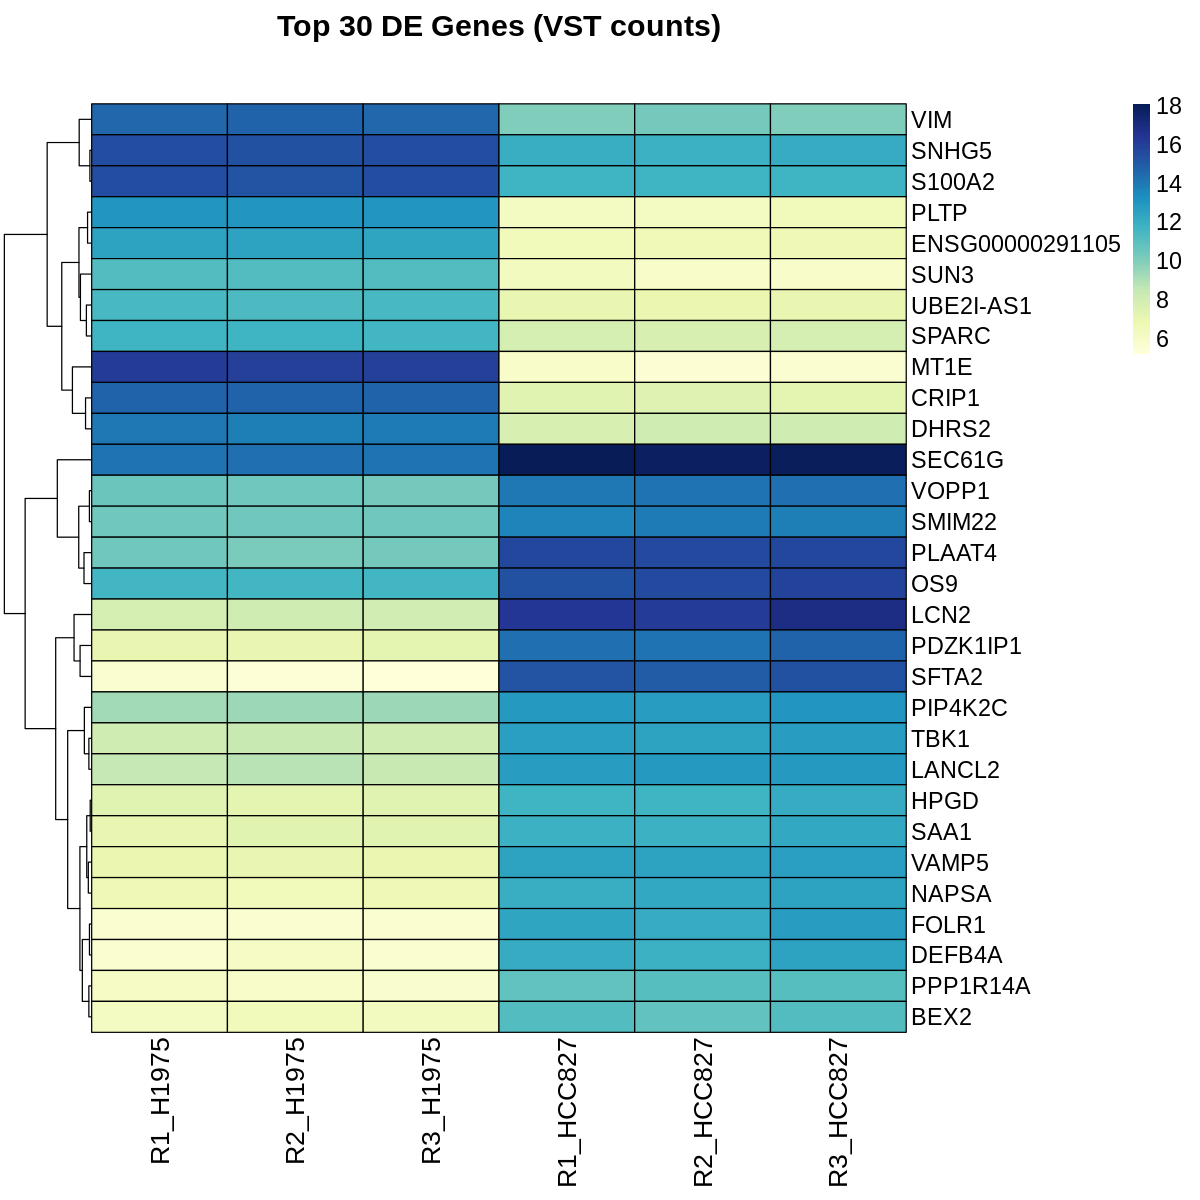

In [91]:
options(repr.plot.width = 10, repr.plot.height = 10)

# --- Determine the top 30 most DE genes ---
top_n <- 30

top_de_genes <- reslfc_df_sig %>%
  arrange(padj, -abs(log2FoldChange)) %>%
  head(top_n)

# Extract VST-transformed data instead of raw counts
# 'vsd' is your Variance Stabilizing Transformation object from the PCA step
# assay(vsd) gives you the matrix of transformed, normalized data
vst_mat <- assay(vsd)

# Subset the VST matrix for your top genes
top_counts_vst <- vst_mat[top_de_genes$gene_symbol, ]

# --- Generate a color palette ---
colors <- colorRampPalette(brewer.pal(n = 9, name = "YlGnBu"))(100)

# --- Create the pheatmap ---
pheatmap(top_counts_vst,
         color = colors,
         border_color="black",
         show_rownames = TRUE,
         show_colnames = TRUE,
         cluster_rows = TRUE,
         cluster_cols = FALSE,
         fontsize_row = 14, # Adjust as needed
         fontsize_col = 16,
         fontsize = 14,
         main="Top 30 DE Genes (VST counts)\n",
         angle_row = 45,  # Rotate gene names if needed
         hjust_row = 0, # Adjust horizontal justification of row names
         angle_col = 90)

## **Differential Transcript Expression**

**Transcript-level workflow (overview)**

The transcript-level analysis mirrors the gene-level pipeline but keeps transcript identifiers (isoforms) as features. Key points:
- Counts must be raw integers for DESeq2. If you derived abundances (TPM), import with `tximport` instead and consider `countsFromAbundance` options.
- We build a `DESeqDataSet` for transcripts (`tdds`), pre-filter low-count transcripts, run `DESeq()`, then transform with `vst()` for PCA/heatmaps.
- Use `lfcShrink()` for stable transcript log2 fold changes prior to plotting and ranking.

**Prepare transcript count matrix**

Convert the annotated `transcript_matrix` into a numeric matrix and set transcript symbols as row names. Confirm sample order matches `sample_info` before creating the `DESeqDataSet`. If names don't match, re-order the columns or fix metadata row names.

In [92]:
rownames(transcript_matrix) <- transcript_matrix[[1]]
transcript_matrix[[1]] <- NULL
transcript_matrix <- as.matrix(transcript_matrix)
head(transcript_matrix)

,R1_H1975,R2_H1975,R3_H1975,R1_HCC827,R2_HCC827,R3_HCC827
ARF5-201,5674.0000,6245.00000,4945.0000,3943.0000,3482.0000,4046.00000
M6PR-201,849.0000,779.00000,745.0000,736.0000,355.0000,752.00000
ESRRA-201,0.0000,0.22534,0.0000,0.0000,0.0000,0.55645
FKBP4-201,546.0000,716.00000,483.0000,999.0000,807.0000,1309.00000
NDUFAF7-201,140.0000,136.00000,105.0000,70.0000,36.0000,96.00000
FUCA2-201,924.4368,1306.97240,845.3776,823.3936,423.3404,817.23085


In [93]:
# Validate that the sample info metadata matches the samples on the matrix
all(rownames(sample_info) == colnames(transcript_matrix))

[1] TRUE

#### The dds object (DESeqDataSetFromMatrix)

**DESeqDataSet for transcripts**

This creates `tdds`, the transcript-level `DESeqDataSet`. As with genes, ensure the `group` column is a factor with correct reference level. Rounding ensures integer counts if needed. The object stores counts, metadata, and the design formula for modeling.

In [94]:
# Create the DESeqDataSet
tdds <- DESeqDataSetFromMatrix(
  countData = round(transcript_matrix),
  colData = sample_info,
  design = ~group # Use 'group' as your design variable
)

tdds

converting counts to integer mode



class: DESeqDataSet 
dim: 121620 6 
metadata(1): version
assays(1): counts
rownames(121620): ARF5-201 M6PR-201 ... CD99-279 CD99-280
rowData names(0):
colnames(6): R1_H1975 R2_H1975 ... R2_HCC827 R3_HCC827
colData names(1): group

Filter

In [95]:
smallestGroupSize <- 3
keep <- rowSums(counts(tdds) >= 10) >= smallestGroupSize
tdds <- tdds[keep,]

tdds <- DESeq(tdds)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [96]:
summary(tdds)

[1] "DESeqDataSet object of length 22474 with 22 metadata columns"

Cell line H1975 was set as the reference level, and HCC827 will be compared to it.

In [97]:
resultsNames(tdds)

[1] "Intercept"             "group_HCC827_vs_H1975"

#### VST and PCA

**Transform & PCA (transcripts)**

Apply `vst()` to the transcript `DESeqDataSet` for variance stabilization before PCA and clustering. Use the transformed data only for visualization — statistical tests use raw counts stored in `tdds`. PCA helps detect batch effects or sample outliers at the transcript level.

using ntop=1500 top features by variance



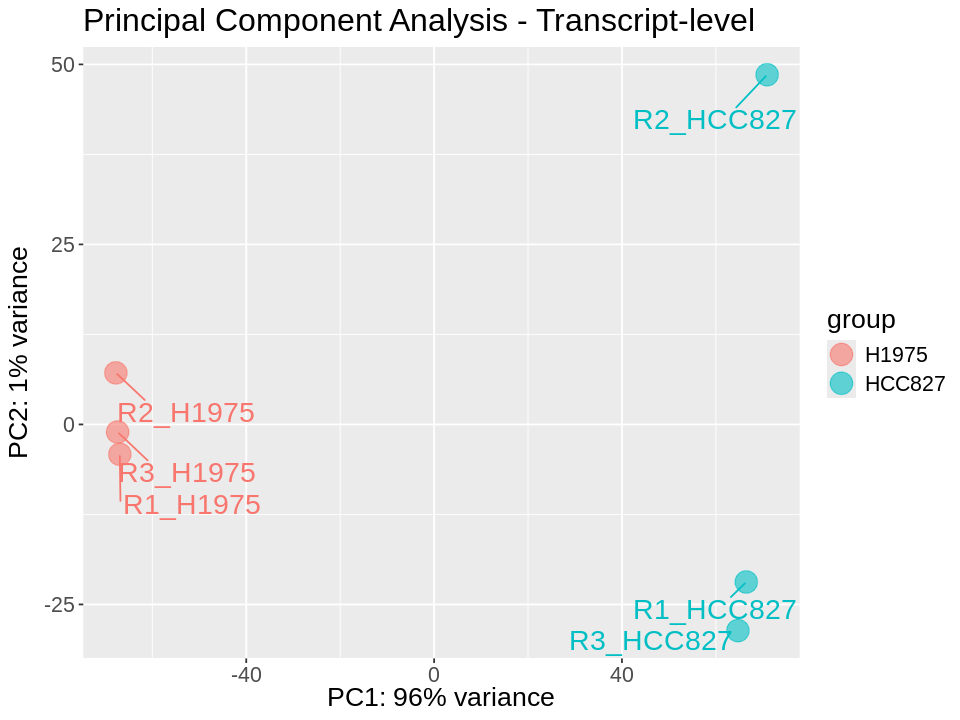

In [98]:
options(repr.plot.width = 8, repr.plot.height = 6)

tvsd <- vst(tdds, blind=TRUE)
tpca_data <- plotPCA(tvsd, intgroup="group", returnData=TRUE, ntop=1500)
tpercentVar <- round(100 * attr(tpca_data, "percentVar"))

ggplot(tpca_data, aes(PC1, PC2, color=group)) +
  geom_point(size=6, alpha=0.6) +
  geom_text_repel(aes(label=as.character(name)),
                  hjust=0, vjust=3, size=6,
                  show.legend = FALSE) +
  xlab(paste0("PC1: ",percentVar[1],"% variance")) +
  ylab(paste0("PC2: ",percentVar[2],"% variance")) +
  labs(title = "Principal Component Analysis - Transcript-level")+
  theme(text=element_text(size=16))

**Sample distance matrix**

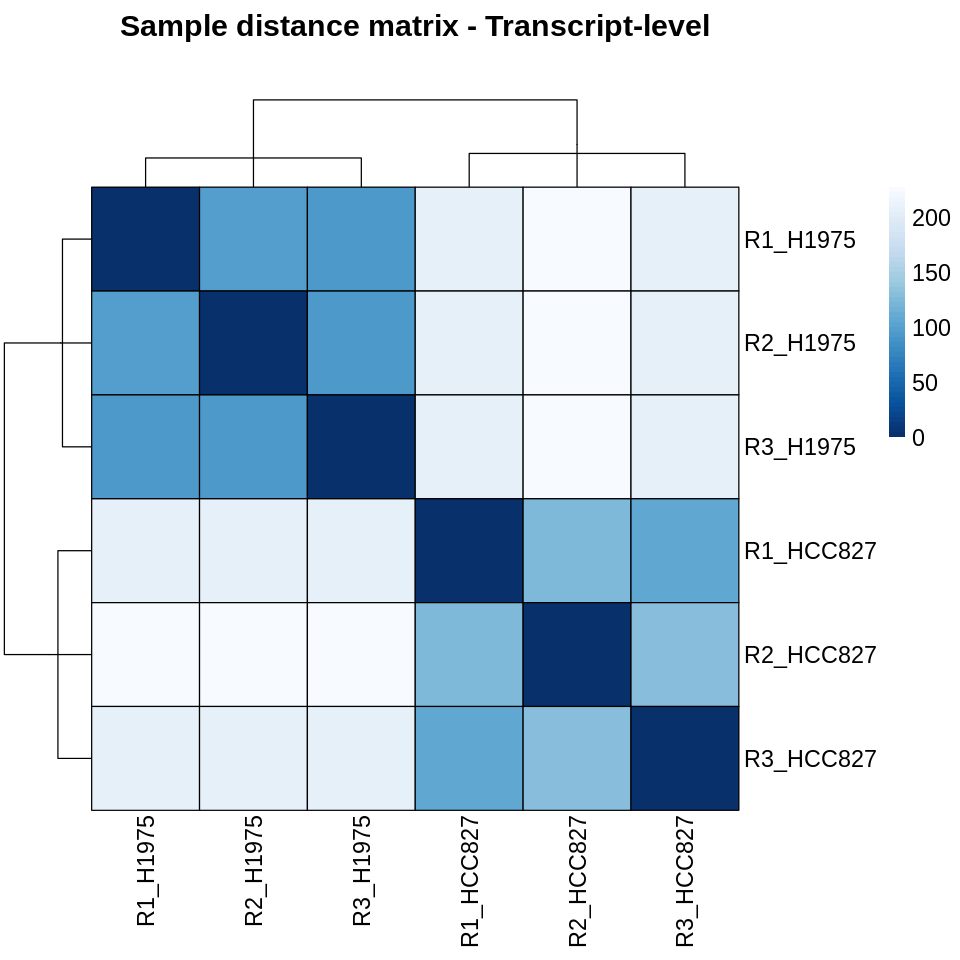

In [99]:
options(repr.plot.width = 8, repr.plot.height = 8)

tsampleDists <- dist(t(assay(tvsd)))

tsampleDistMatrix <- as.matrix(tsampleDists)
colors <- colorRampPalette(rev(brewer.pal(9, "Blues")))(50)

pheatmap(tsampleDistMatrix,
                    color=colors,
                    border_color="black",
                    clustering_callback=ordering_callback,
                    main="Sample distance matrix - Transcript-level\n",
                    fontsize=14, fontsize_row=14, fontsize_col=14, angle_col=90)

#### Significance Analysis

**Extract transcript-level results**

Use `results()` on `tdds` to extract transcript-level differential expression statistics. As before, check `summary()`. Interpret `padj` for FDR-controlled significance.

In [100]:
tres05 <- results(tdds, alpha=0.05)

summary(res05)


out of 19639 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 6067, 31%
LFC < 0 (down)     : 6188, 32%
outliers [1]       : 12, 0.061%
low counts [2]     : 0, 0%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



Order by LogFoldChange

In [101]:
tres05[order(tres05$log2FoldChange),]

log2 fold change (MLE): group HCC827 vs H1975 
Wald test p-value: group HCC827 vs H1975 
DataFrame with 22474 rows and 6 columns
             baseMean log2FoldChange     lfcSE      stat       pvalue
            <numeric>      <numeric> <numeric> <numeric>    <numeric>
CTSA-220     1267.449       -13.4261  1.190270  -11.2799  1.64937e-29
MT1E-201    28416.326       -13.3902  0.438338  -30.5476 6.08168e-205
YWHAB-201     947.140       -13.0058  1.208427  -10.7626  5.17187e-27
SNRPN-202    1566.530       -12.7697  1.189445  -10.7358  6.91097e-27
ADIRF-201     773.364       -12.7133  1.191592  -10.6692  1.41850e-26
...               ...            ...       ...       ...          ...
SFTA2-201    16181.79        13.9634  0.542478  25.74006 4.16461e-146
SUPT4H1-201   1461.27        14.3499  1.191118  12.04744  2.00061e-33
BEX3-204      1618.01        14.4962  1.191874  12.16249  4.92332e-34
VAMP5-201     1782.73        14.6359  1.199730  12.19935  3.13308e-34
NDUFB2-201    2600.36        15

Order and filter by adjusted p-value

In [102]:
tres05[order(tres05$padj),]

log2 fold change (MLE): group HCC827 vs H1975 
Wald test p-value: group HCC827 vs H1975 
DataFrame with 22474 rows and 6 columns
              baseMean log2FoldChange     lfcSE      stat       pvalue
             <numeric>      <numeric> <numeric> <numeric>    <numeric>
LCN2-201      27386.10        8.97648  0.170170   52.7501  0.00000e+00
PDZK1IP1-201   8548.28        8.21840  0.213437   38.5050  0.00000e+00
CRIP1-201     10186.50       -9.56799  0.244422  -39.1454  0.00000e+00
MT1E-201      28416.33      -13.39019  0.438338  -30.5476 6.08168e-205
IFITM2-205     6422.08       -4.46692  0.146393  -30.5132 1.74344e-204
...                ...            ...       ...       ...          ...
NPM1-252       98.7905      -0.775056   2.68223 -0.288960           NA
TPT1-218       63.5854       1.266233   3.72819  0.339637           NA
UQCRH-218     251.0285       0.383037   1.96152  0.195275           NA
RPL11-224     140.5282       4.303022   1.89569  2.269901           NA
RPLP0-259     243.0

In [103]:
subset(tres05[order(tres05$padj),], padj < 0.05)

log2 fold change (MLE): group HCC827 vs H1975 
Wald test p-value: group HCC827 vs H1975 
DataFrame with 10247 rows and 6 columns
                baseMean log2FoldChange     lfcSE      stat       pvalue
               <numeric>      <numeric> <numeric> <numeric>    <numeric>
LCN2-201        27386.10        8.97648  0.170170   52.7501  0.00000e+00
PDZK1IP1-201     8548.28        8.21840  0.213437   38.5050  0.00000e+00
CRIP1-201       10186.50       -9.56799  0.244422  -39.1454  0.00000e+00
MT1E-201        28416.33      -13.39019  0.438338  -30.5476 6.08168e-205
IFITM2-205       6422.08       -4.46692  0.146393  -30.5132 1.74344e-204
...                  ...            ...       ...       ...          ...
MRPL40-201    3222.25239      -0.297744  0.130803  -2.27628    0.0228290
UQCRC1-202       7.72791      -1.977254  0.868798  -2.27585    0.0228549
RAMAC-201     1111.34879      -0.312498  0.137317  -2.27575    0.0228612
LINC00960-209   68.42930      -0.781567  0.343443  -2.27569    0.022

#### Shrinkage

**Transcript log fold-change shrinkage**

Apply `lfcShrink()` to obtain stabilized log2 fold-change estimates for transcripts. Shrunk LFCs reduce noise-driven extreme values and are preferable for plots and ranking transcripts by effect size.

In [104]:
treslfc <- lfcShrink(tdds, coef = 2, type = "apeglm")

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



In [105]:
treslfc

log2 fold change (MAP): group HCC827 vs H1975 
Wald test p-value: group HCC827 vs H1975 
DataFrame with 22474 rows and 5 columns
             baseMean log2FoldChange     lfcSE      pvalue        padj
            <numeric>      <numeric> <numeric>   <numeric>   <numeric>
ARF5-201     4561.467      0.1812121  0.201343 3.60161e-01 4.79601e-01
M6PR-201      666.940      0.2787191  0.168995 9.48634e-02 1.64756e-01
FKBP4-201     864.440      1.5169902  0.215874 7.03834e-13 1.13720e-11
NDUFAF7-201    87.988     -0.2402602  0.285523 3.80163e-01 4.99436e-01
FUCA2-201     800.374      0.0884096  0.197139 6.49567e-01 7.46313e-01
...               ...            ...       ...         ...         ...
CD99-249      30.2573    -2.02457079  0.512011 1.72775e-05 8.48864e-05
CD99P1-263    13.8166     0.00402562  0.528495 9.94801e-01 9.96536e-01
SLC25A6-219  165.3775     1.17137093  0.215477 2.68809e-08 2.22540e-07
CD99-276      18.3587     0.26118915  0.449927 5.17910e-01 6.31773e-01
SLC25A6-223   12.42

In [106]:
summary(treslfc)


out of 22474 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 5554, 25%
LFC < 0 (down)     : 6073, 27%
outliers [1]       : 80, 0.36%
low counts [2]     : 0, 0%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [107]:
# Convert reslfc to a data frame
treslfc_df <- as.data.frame(treslfc)
treslfc_df <- tibble::rownames_to_column(treslfc_df, var = "symbol")

# Handling NA values
treslfc_df <- na.omit(treslfc_df)

write.csv(treslfc_df, file="reslfc_df_dte.csv")

**MA Plot**

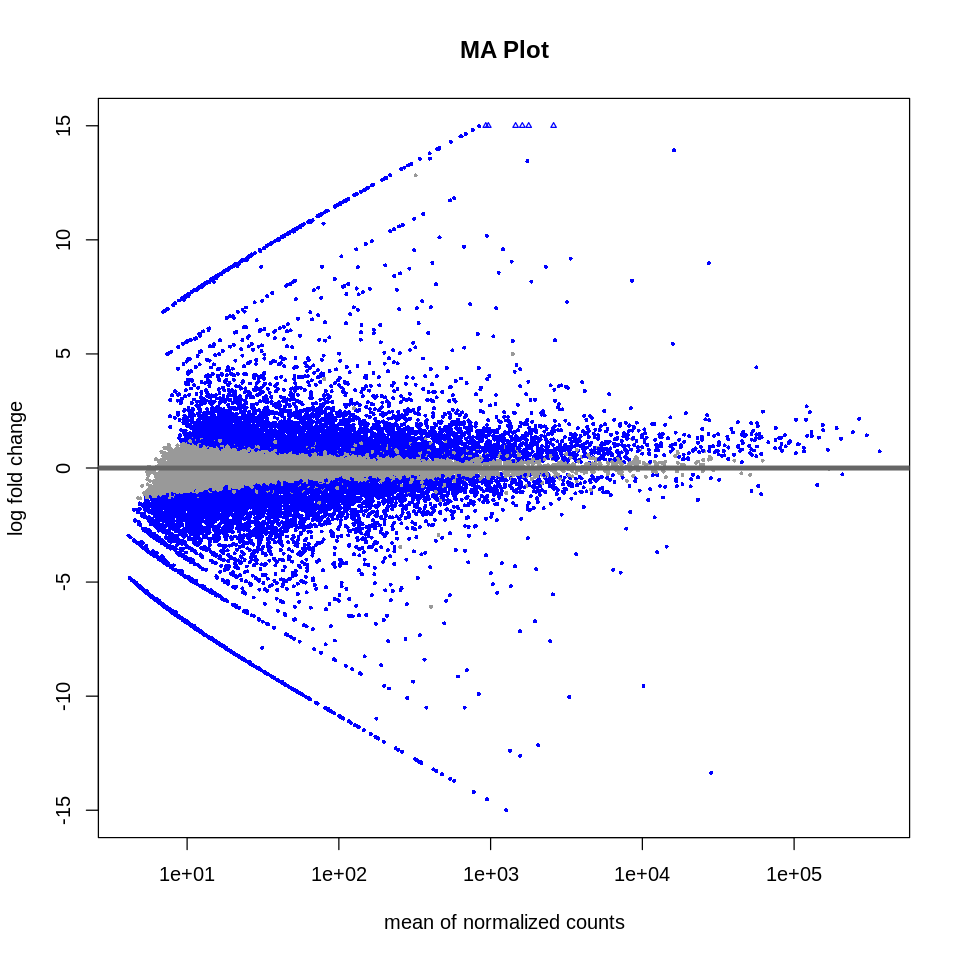

In [108]:
# Create MA Plot

plotMA(treslfc, main="MA Plot", ylim=c(-15,15))

Filter for the adjusted p-value

In [121]:
tres05lfc <- subset(treslfc, padj < 0.05)

summary(tres05lfc)


out of 10247 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 4990, 49%
LFC < 0 (down)     : 5257, 51%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



#### Visualizing Transcript-level Differential Expression

**Volcano plot**

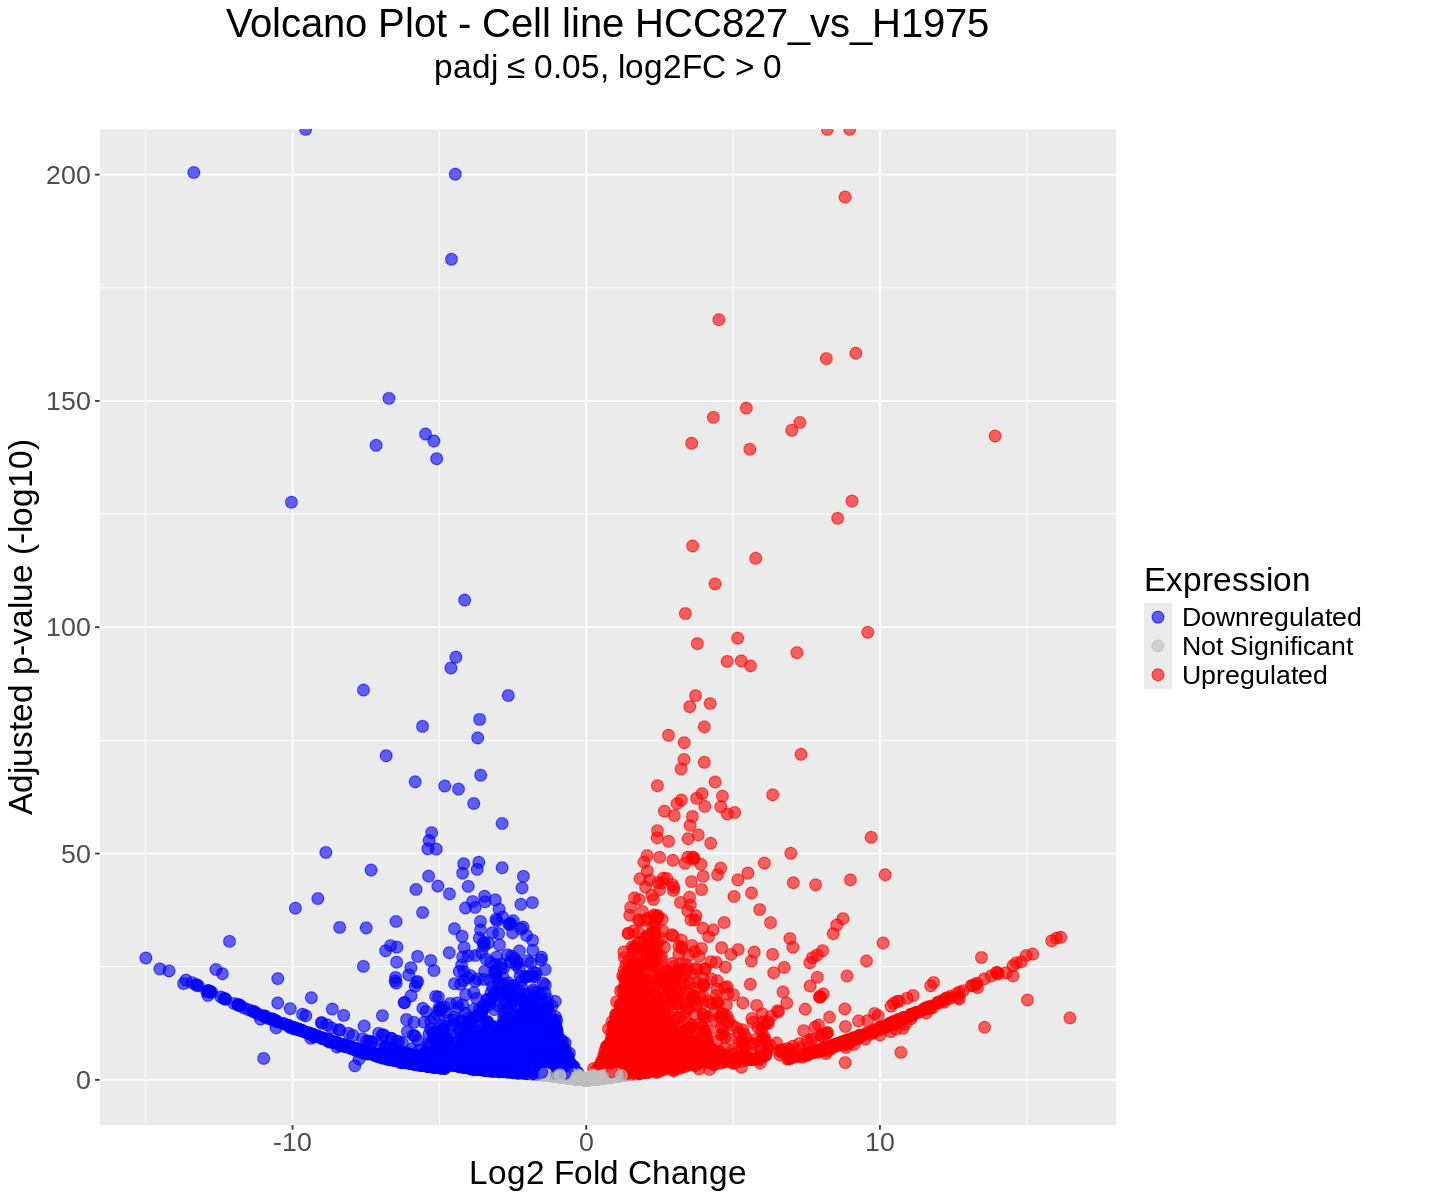

In [109]:
options(repr.plot.width = 12, repr.plot.height = 10)

# Define significance and log2 fold change thresholds
sigThreshold <- 0.05
lfcThreshold <- 0 # Adjust this threshold as needed

# Adding a column for coloring based on significance and fold change
treslfc_df$exp <- with(treslfc_df, ifelse(padj < sigThreshold & log2FoldChange >= lfcThreshold, "Upregulated", ifelse(padj < sigThreshold & log2FoldChange <= -lfcThreshold, "Downregulated", "Not Significant")))

treslfc_df_sig <- treslfc_df %>%
  filter(exp %in% c("Upregulated", "Downregulated")) %>%
  arrange(padj, -abs(log2FoldChange))

# Adjust point size based on significance
treslfc_df$size <- with(treslfc_df, ifelse(padj < sigThreshold & abs(log2FoldChange) >= lfcThreshold, 3,3))

write.csv(treslfc_df_sig, file="reslfc_df_sig_dte.csv")

# Creating a Volcano Plot with conditional coloring and point sizes
tvolc <- ggplot(treslfc_df, aes(x = log2FoldChange, y = -log10(padj), color = exp,
                               size = size)) +
  geom_point(alpha = 0.6, size = 3) +
  scale_color_manual(values = c("Upregulated" = "red", "Downregulated" = "blue",
                                "Not Significant" = "grey")) +
  scale_size_identity() +
  labs(x = "Log2 Fold Change", y = "Adjusted p-value (-log10)",
       title = "Volcano Plot - Cell line HCC827_vs_H1975",
       subtitle = "padj ≤ 0.05, log2FC > 0\n") +
  guides(color = guide_legend(title = "Expression")) +
  coord_cartesian(ylim = c(0, 200)) +
  theme(
    legend.position = "right",
    text = element_text(size=20),
    plot.title = element_text(hjust = 0.5),
    plot.subtitle = element_text(hjust = 0.5)
  )

tvolc

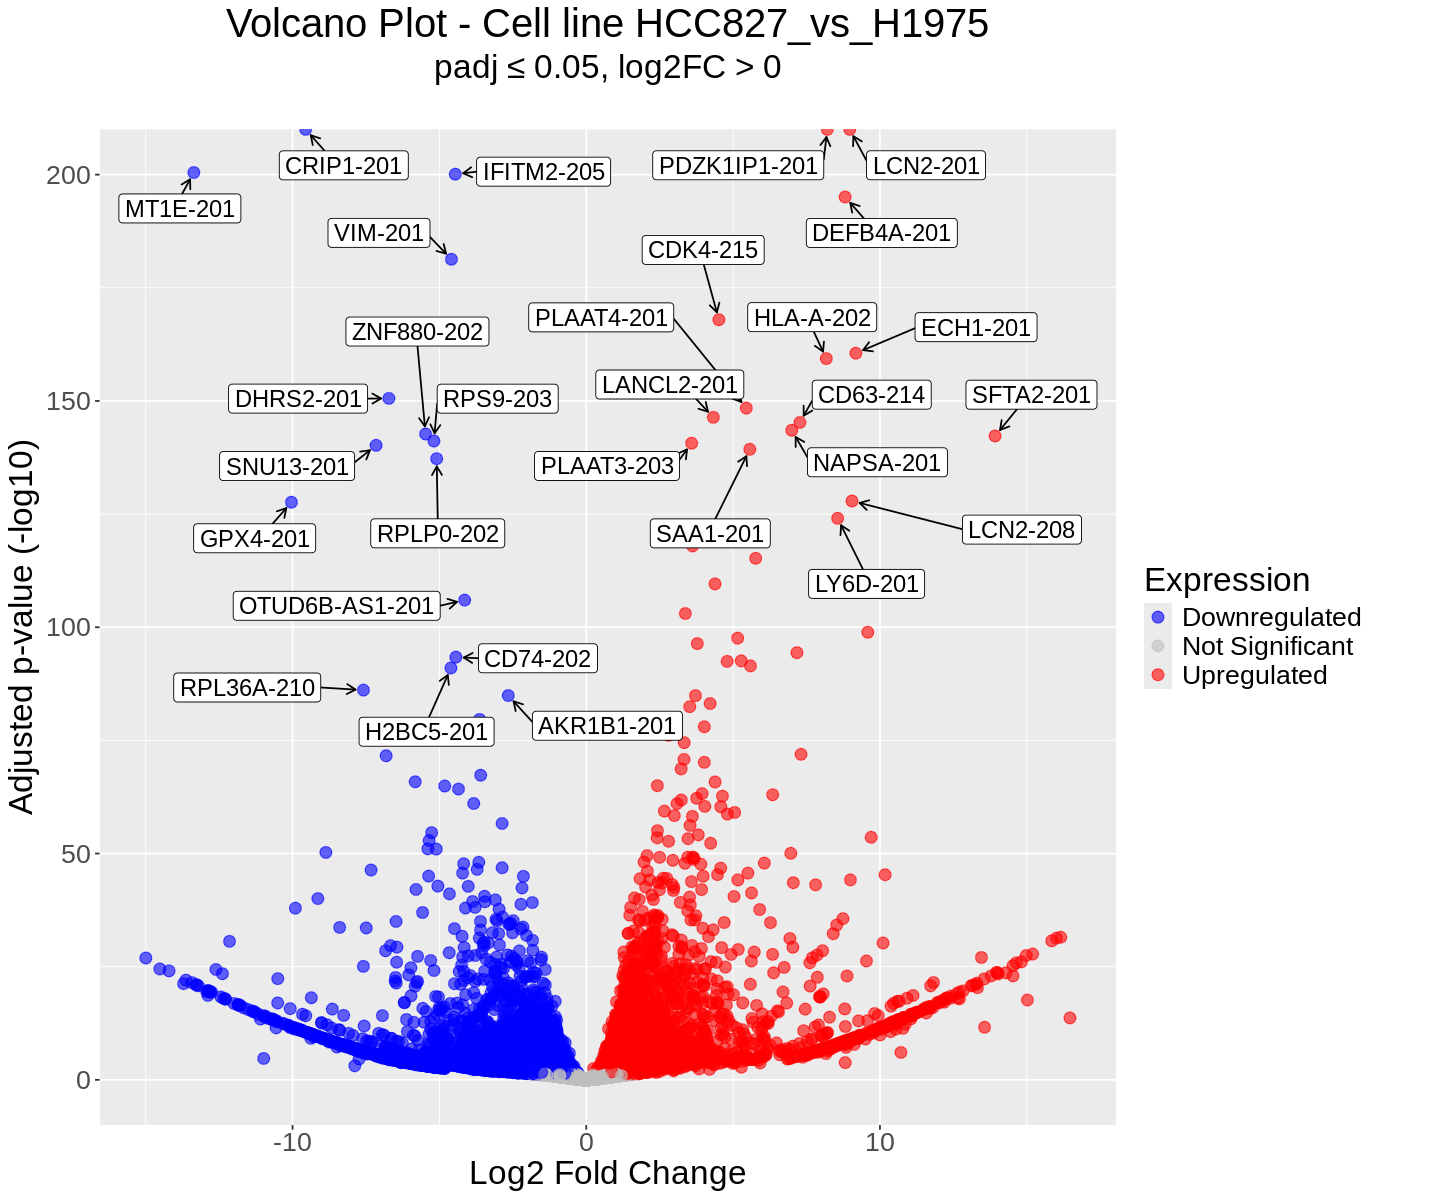

In [110]:
top_n <- 15

# --- Determine the top N most prominent transcripts to label ---
top_transcripts_up <- treslfc_df_sig %>%
  filter(exp == "Upregulated") %>%
  arrange(padj, -abs(log2FoldChange)) %>%
  head(top_n)

top_transcripts_down <- treslfc_df_sig %>%
  filter(exp == "Downregulated") %>%
  arrange(padj, -abs(log2FoldChange)) %>%
  head(top_n)

top_transcripts <- bind_rows(top_transcripts_up, top_transcripts_down)

write.csv(top_transcripts_up, file="top_15_DTE_up.csv")
write.csv(top_transcripts_down, file="top_15_DTE_down.csv")

# --- Add labels to the Volcano Plot using ggrepel ---
tvolc_names <- tvolc +
  geom_label_repel(
    data = top_transcripts,
    aes(label = symbol),
    color = "black", # Set label color to black
    size = 5,
    box.padding = unit(0.8, "lines"),
    point.padding = unit(0.5, "lines"),
    segment.color = 'black',
    segment.size = 0.5,
    arrow = arrow(length = unit(0.01, "npc")),
    max.overlaps = Inf
  )

tvolc_names

**Pheatmap**

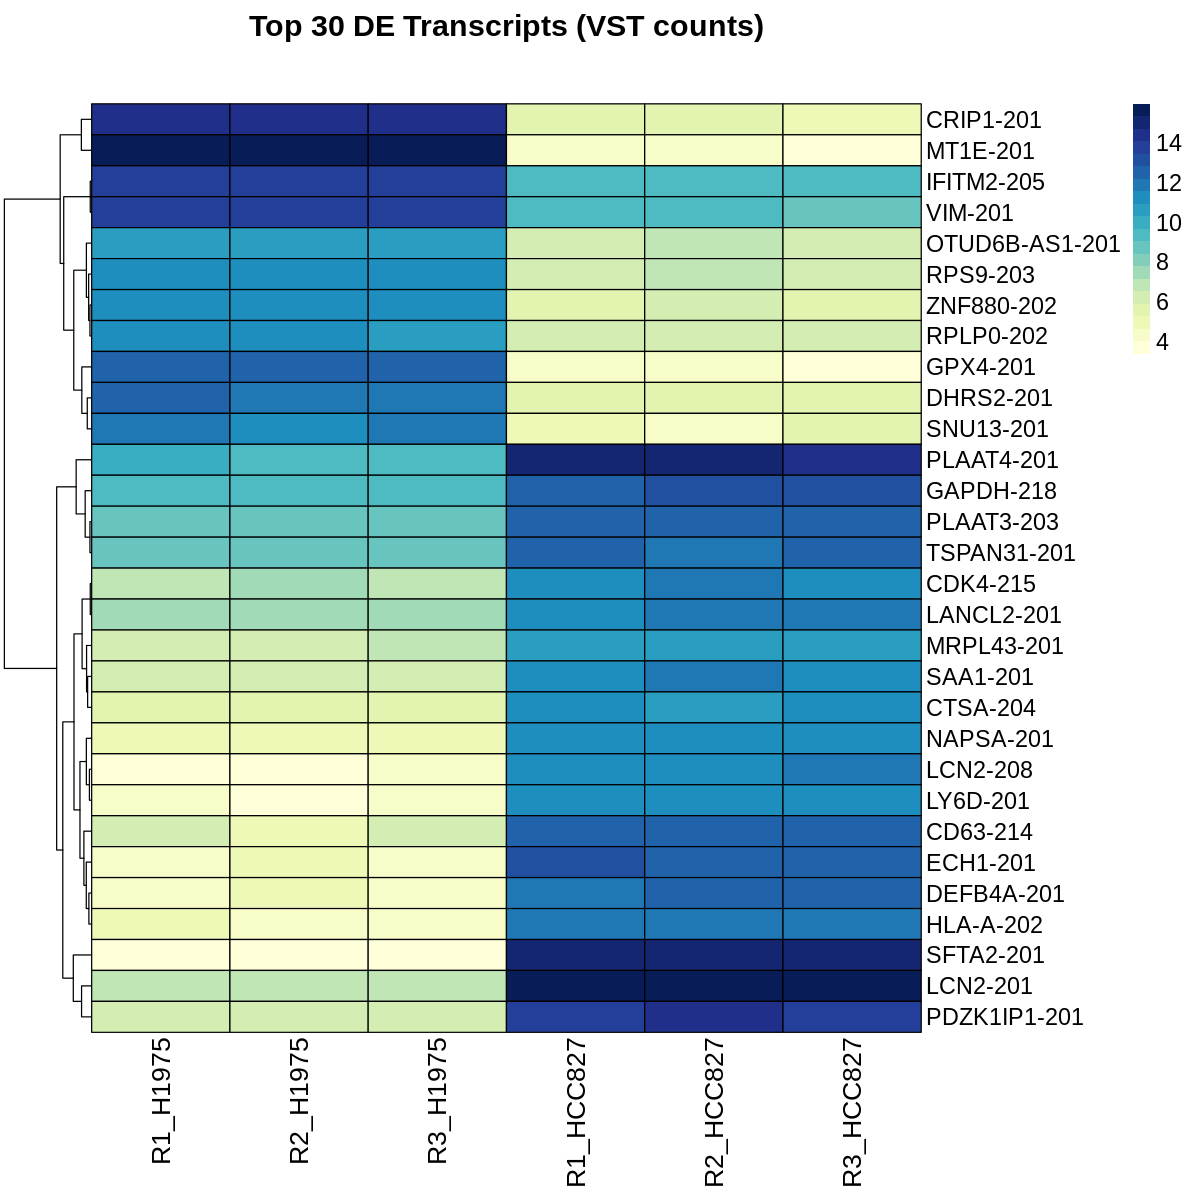

In [111]:
options(repr.plot.width = 10, repr.plot.height = 10)

# --- Determine the top 30 most DE transcripts ---
top_n <- 30

top_de_transcripts <- treslfc_df_sig %>%
  arrange(padj, -abs(log2FoldChange)) %>%
  head(top_n)

# Extract VST-transformed data instead of raw counts
# 'vsd' is your Variance Stabilizing Transformation object from the PCA step
# assay(vsd) gives you the matrix of transformed, normalized data
tvst_mat <- assay(tvsd)

# Subset the VST matrix for your top genes
top_counts_tvst <- tvst_mat[top_de_transcripts$symbol, ]

# --- Generate a color palette ---
colors <- colorRampPalette(brewer.pal(n = 9, name = "YlGnBu"))(20)

# --- Create the pheatmap ---
pheatmap(top_counts_tvst,
         color = colors,
         border_color="black",
         show_rownames = TRUE,
         show_colnames = TRUE,
         cluster_rows = TRUE,
         cluster_cols = FALSE,
         fontsize_row = 14, # Adjust as needed
         fontsize_col = 16,
         fontsize = 14,
         main="Top 30 DE Transcripts (VST counts)\n",
         angle_row = 45,  # Rotate transcript names if needed
         hjust_row = 0, # Adjust horizontal justification of row names
         angle_col = 90)

## **Gene x Transcript Expression Relationships**
In this section, we analyze the relationship between the significant differentially expressed (DE) genes and their specific isoforms. This helps determine if a gene's differential expression is driven by a single dominant isoform, a general upregulation of all isoforms, or an isoform switch.

We will use the VST-transformed count data (generated during the PCA steps). This ensures that the expression values compared in the final plot are normalized for sequencing depth and variance-stabilized.

#### **Methodology**

* **Map**: Link every transcript to its parent gene using biomaRt.

* **Select**: Focus on specific genes of interest (e.g., HLA-A, LCN2, MT1E).

* **Extract**: Retrieve VST-normalized expression data for both the genes and their transcripts.

* **Visualize**: Plot gene vs. transcript expression side-by-side.

#### **Step 1**: Retrieve Comprehensive Gene-Transcript Mapping
We first need a map linking every transcript ID to its gene symbol.

**Retrieve gene↔transcript mapping**

We query Ensembl via `biomaRt` to get transcript -> gene mappings. This mapping is used to relate transcript-level results back to genes for the combined visualizations. If your session cannot reach Ensembl, provide a precomputed mapping table instead to avoid network failures.

In [112]:
# 1. Define attributes to retrieve from Ensembl
tx_gene_attributes <- c("ensembl_transcript_id",
                        "ensembl_gene_id",
                        "external_transcript_name",
                        "external_gene_name")

# 2. Retrieve mapping using biomaRt
# Note: 't_ids' is the list of transcript IDs you created earlier
tx_gene_map <- getBM(attributes = tx_gene_attributes,
                     filters = "ensembl_transcript_id",
                     values = t_ids,
                     mart = ensembl)

# 3. Clean and Process the Map
# Fill empty names with IDs to ensure no missing labels
tx_gene_map <- tx_gene_map %>%
  mutate(external_transcript_name = ifelse(external_transcript_name == "" | is.na(external_transcript_name),
                                           ensembl_transcript_id, external_transcript_name)) %>%
  mutate(external_gene_name = ifelse(external_gene_name == "" | is.na(external_gene_name),
                                     ensembl_gene_id, external_gene_name)) %>%
  distinct(external_transcript_name, .keep_all = TRUE)

# Preview the map
head(tx_gene_map)

,ensembl_transcript_id,ensembl_gene_id,external_transcript_name,external_gene_name
,<chr>,<chr>,<chr>,<chr>
1,ENST00000284856,ENSG00000154620,TMSB4Y-201,TMSB4Y
2,ENST00000282964,ENSG00000229336,SREK1IP1P1-201,SREK1IP1P1
3,ENST00000286808,ENSG00000156282,CLDN17-201,CLDN17
4,ENST00000290349,ENSG00000159228,CBR1-201,CBR1
5,ENST00000291572,ENSG00000160216,AGPAT3-201,AGPAT3
6,ENST00000291527,ENSG00000160182,TFF1-201,TFF1


#### **Step 2**: Select Genes of Interest
We select specific candidate genes to inspect. We could use any set of genes that have >2 isoforms differentially expressed.

In [113]:
# Define the specific genes to investigate
keep_genes <- c("MT1E", "CTSA", "PLAAT3", "LCN2", "CRIP1", "HLA-A", "PLAAT4", "TRIM52-AS1", "CASC9", "YWHAB")

# Filter the map to get only the transcripts belonging to these genes
target_mapping <- tx_gene_map %>%
  filter(external_gene_name %in% keep_genes)

# Extract the list of transcript names for these genes
target_tx_ids <- target_mapping$external_transcript_name

message("Transcripts identified for plotting: ", length(target_tx_ids))

Transcripts identified for plotting: 143



#### **Step 3**: Extract VST Expression Data
We extract the normalized expression data from the VST objects (vsd for genes, tvsd for transcripts).

**Extract VST values for plotting**

Here we extract variance-stabilized expression values for selected genes from the `vsd` object. These values are used for comparative plots (gene vs transcript). They are not used for statistical testing.

In [114]:
# Extract VST data for the selected genes from the 'vsd' object
gene_vst_data <- assay(vsd)[keep_genes, ] %>%
  as.data.frame() %>%
  rownames_to_column("feature_id") %>%
  pivot_longer(cols = -feature_id, names_to = "sample", values_to = "vst_expression") %>%
  mutate(
    type = "Gene",
    gene_group = feature_id # For genes, the grouping variable is just the gene name itself
  )

**Extract VST values for transcripts**

Extract variance-stabilized expression values for the transcripts of interest from `tvsd`. We then reshape to long format and join the mapping table so each transcript has its parent gene attached for plotting.

In [115]:
# Extract VST data for the associated transcripts from the 'tvsd' object
# We filter 'assay(tvsd)' to only include the transcripts in 'target_tx_ids'
tx_vst_data <- assay(tvsd)
tx_vst_data <- tx_vst_data[rownames(tx_vst_data) %in% target_tx_ids, ] %>%
  as.data.frame() %>%
  rownames_to_column("feature_id") %>%
  pivot_longer(cols = -feature_id, names_to = "sample", values_to = "vst_expression") %>%
  mutate(type = "Transcript") %>%
  # Join with our mapping table so we know which Gene this transcript belongs to
  left_join(target_mapping, by = c("feature_id" = "external_transcript_name")) %>%
  mutate(gene_group = external_gene_name) %>%
  # Select only the columns we need to match the gene_vst_data structure
  dplyr::select(feature_id, sample, vst_expression, type, gene_group)

**Combine data**

In [116]:
# Combine both datasets into one for plotting
plot_data <- bind_rows(gene_vst_data, tx_vst_data) %>%
  # Add the sample metadata (e.g., Condition/Group) from 'sample_info'
  left_join(sample_info %>% rownames_to_column("sample"), by = "sample")

# Preview data
plot_data %>%
  slice_sample(n = 6)

feature_id,sample,vst_expression,type,gene_group,group
<chr>,<chr>,<dbl>,<chr>,<chr>,<fct>
TRIM52-AS1-206,R1_HCC827,6.787506,Transcript,TRIM52-AS1,HCC827
YWHAB-209,R2_H1975,6.709418,Transcript,YWHAB,H1975
CRIP1-210,R2_H1975,6.527120,Transcript,CRIP1,H1975
PLAAT4,R1_HCC827,15.654148,Gene,PLAAT4,HCC827
TRIM52-AS1-207,R3_HCC827,6.857357,Transcript,TRIM52-AS1,HCC827
TRIM52-AS1-201,R2_H1975,5.172180,Transcript,TRIM52-AS1,H1975


#### **Step 4**: Visualization (Gene vs. Transcripts)

**Lollipop plot**

Each panel represents one Gene. Inside each panel, the leftmost lollipop plots shows the total Gene expression, followed by the expression of its individual Transcripts.

In [117]:
# PREPARE DATA: Calculate Medians
# We group by feature, condition, gene family, and type to get one value per group
median_plot_data <- plot_data %>%
  group_by(feature_id, group, gene_group, type) %>%
  summarise(median_vst = median(vst_expression, na.rm = TRUE), .groups = "drop")

# ENFORCE ORDERING
# Ensure "Gene" is the first level so it appears in the left column
median_plot_data <- median_plot_data %>%
  mutate(type = factor(type, levels = c("Gene", "Transcript"))) %>%
  arrange(gene_group, type, feature_id)

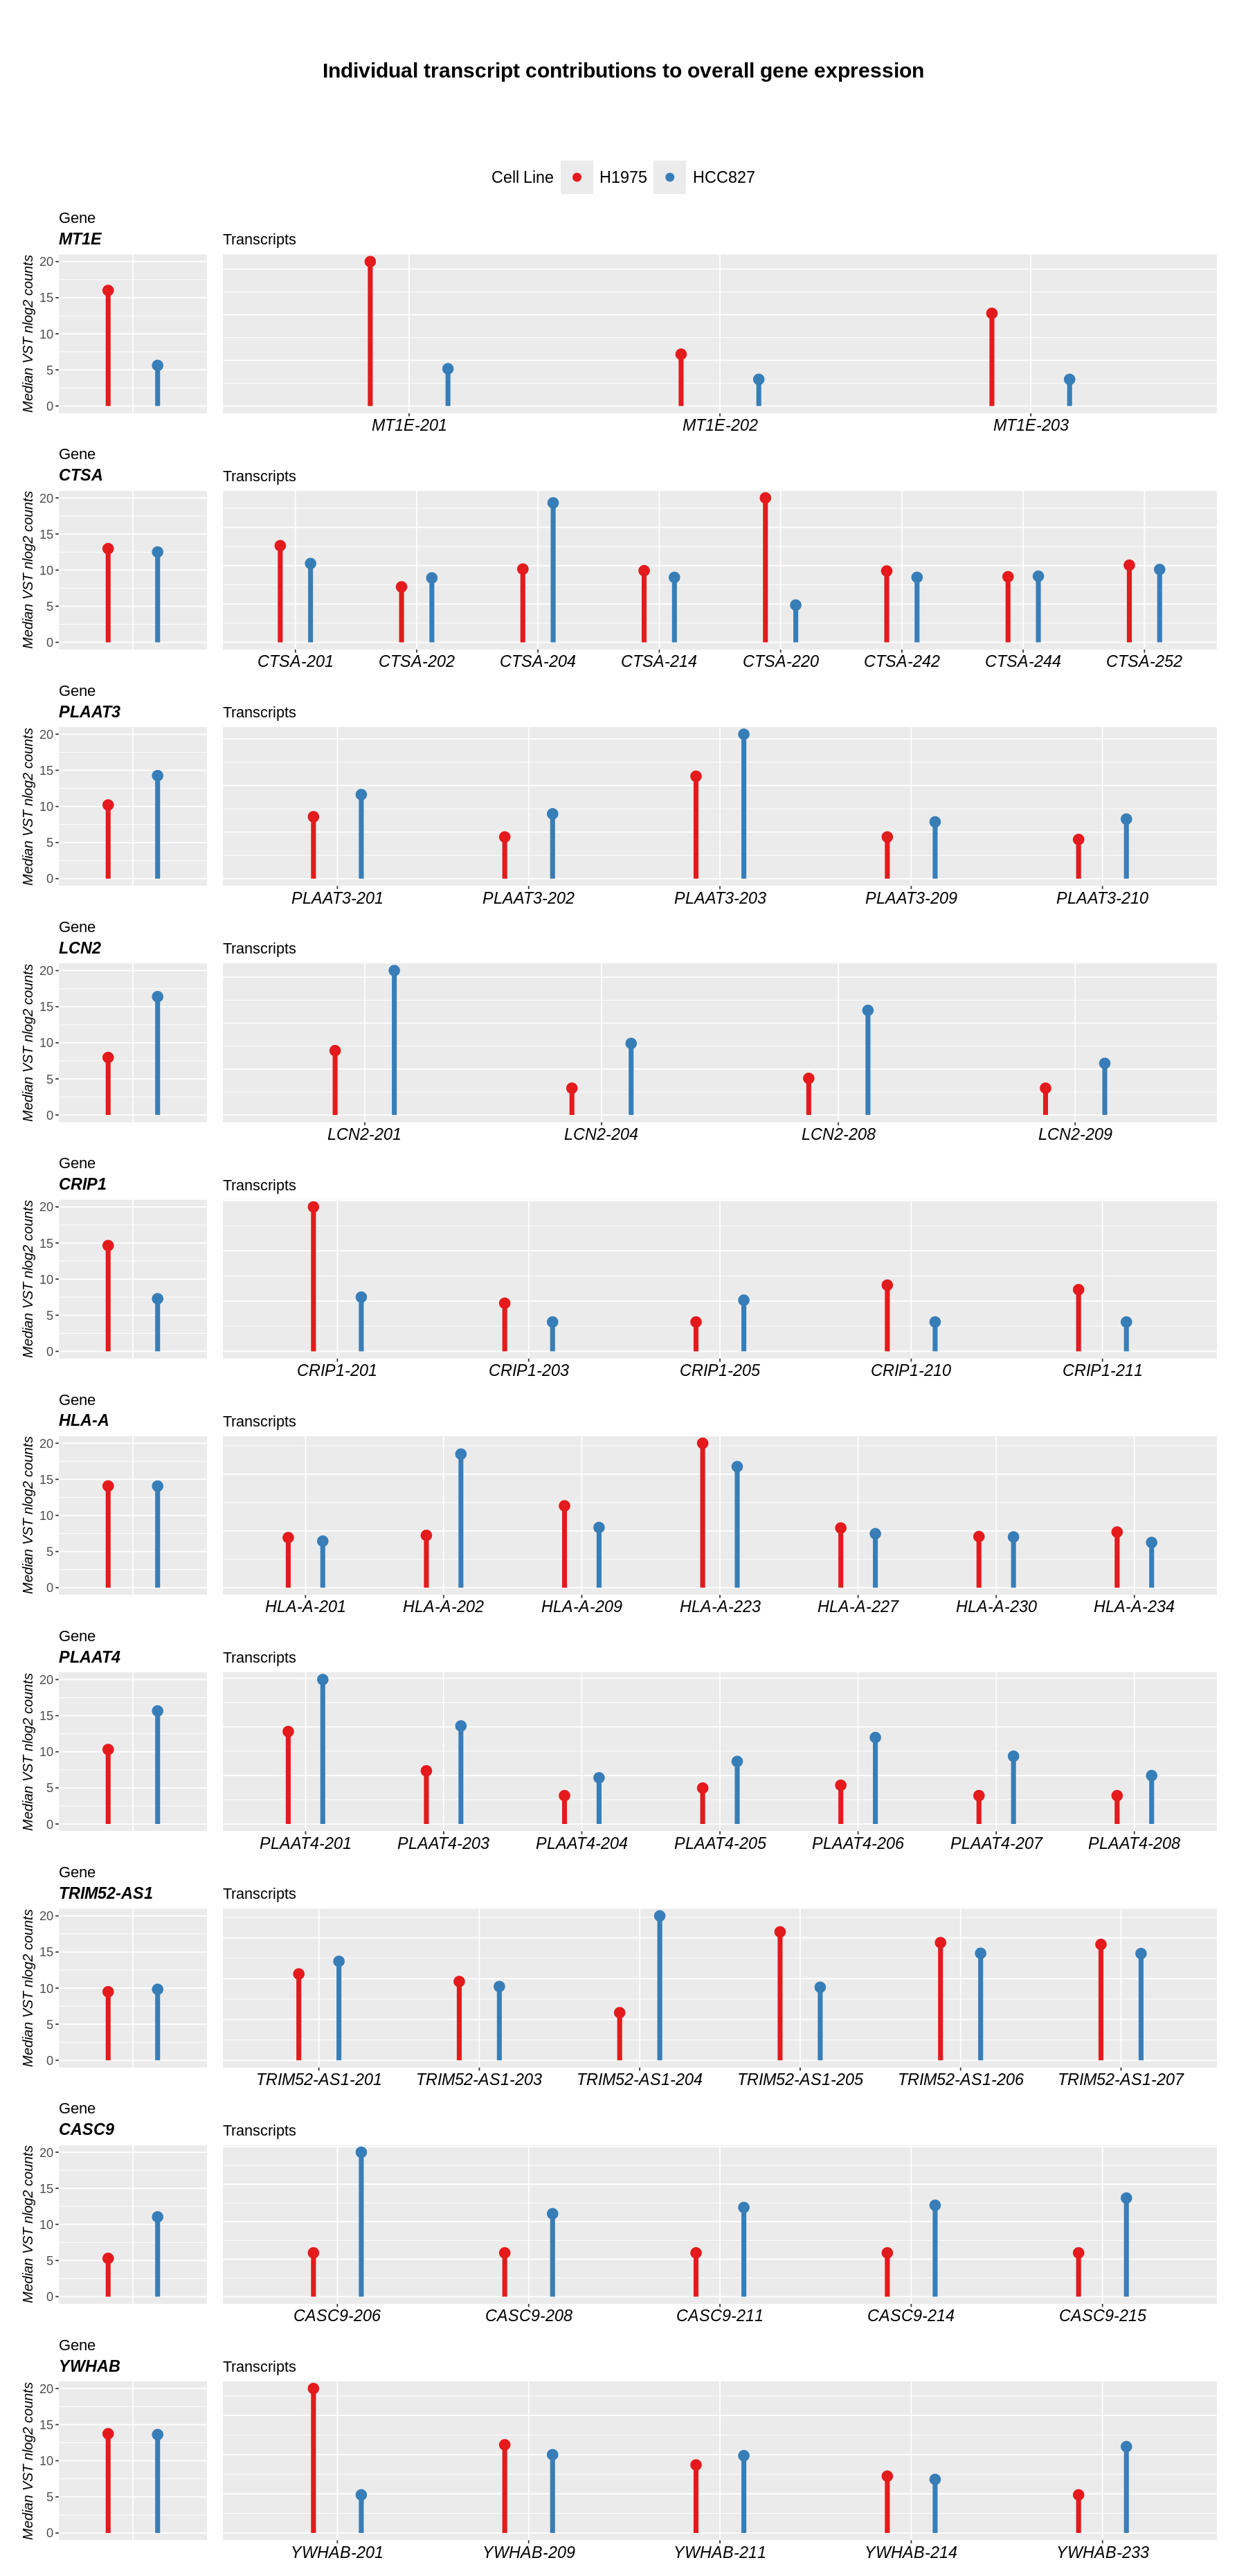

In [118]:
# 1. PREPARE DATA
# Ensure "Gene" comes first in factor levels so logic holds
median_plot_data$type <- factor(median_plot_data$type, levels = c("Gene", "Transcript"))

# 2. EXTRACT A SHARED LEGEND
# We create a dummy plot just to get a perfectly styled legend
dummy_plot <- ggplot(median_plot_data, aes(x = feature_id, y = median_vst, color = group)) +
  geom_point(size = 3) +
  scale_color_brewer(palette = "Set1") +
  labs(color = "Cell Line") +
  theme(
    legend.position = "top",
    legend.justification = "center",
    legend.key.size = unit(1, "cm"),
    legend.text = element_text(size = 14),
    legend.title = element_text(size = 14)
  )

shared_legend <- get_legend(dummy_plot)

# 3. FUNCTION TO CREATE A FIXED-RATIO ROW (GENE | TRANSCRIPT)
create_aligned_row <- function(gene_name) {

  # Filter data for this specific gene
  gene_data <- median_plot_data %>% filter(gene_group == gene_name)

  # --- LEFT PLOT: GENE ONLY ---
  p_left <- gene_data %>%
    filter(type == "Gene") %>%
    ggplot(aes(x = feature_id, y = median_vst, color = group)) +
    geom_errorbar(aes(ymin = 0, ymax = median_vst), width = 0, linewidth = 2, position = position_dodge(0.8)) +
    geom_point(size = 4, position = position_dodge(0.8)) +
    scale_color_brewer(palette = "Set1") +
    labs(y = "Median VST nlog2 counts", x = "", title = "Gene", subtitle = gene_name) +
    coord_cartesian(ylim = c(0, 20)) +
    theme(
      legend.position = "none", # No legend here
      axis.text.x = element_blank(), # No X label for Gene (redundant)
      axis.ticks.x = element_blank(),
      plot.subtitle = element_text(size = 14, face = "bold.italic"), # Big Gene Label
      axis.title.y = element_text(size = 12, face = "italic"),
      axis.text.y = element_text(size = 11),
      plot.margin = margin(l = 20, r = 0.5)
    )

  # --- RIGHT PLOT: TRANSCRIPTS ONLY ---
  p_right <- gene_data %>%
    filter(type == "Transcript") %>%
    ggplot(aes(x = feature_id, y = median_vst, color = group)) +
    geom_errorbar(aes(ymin = 0, ymax = median_vst), width = 0, linewidth = 2, position = position_dodge(0.5)) +
    geom_point(size = 4, position = position_dodge(0.5)) +
    scale_color_brewer(palette = "Set1") +
    labs(y = "", x = "", subtitle = "Transcripts") +
    theme(
      legend.position = "none",
      axis.text.x = element_text(angle = 0, hjust = 0.5, size = 14, color = "black", face = "italic"),
      plot.subtitle = element_text(size = 13, color = "black"),
      axis.text.y = element_blank(), # Optional: hide Y axis to declutter (since Left plot has it)
      axis.ticks.y = element_blank(),
      plot.margin = margin(l = 0, r = 25)
    )

  # --- COMBINE LEFT & RIGHT WITH FIXED RATIO ---
  # align = "h" ensures the x-axis lines match up perfectly
  plot_row <- plot_grid(p_left, p_right, align = "h", axis = "bt", rel_widths = c(0.8, 4))

  return(plot_row)
}

# 4. GENERATE & STACK ROWS
# Create a list of aligned rows
row_list <- lapply(keep_genes, create_aligned_row)

# Stack them vertically
stacked_grid <- plot_grid(plotlist = row_list, ncol = 1, align = "v")

# 5. CREATE TITLE AND COMBINE
# Create the title object using ggdraw
title_gg <- ggdraw() +
  draw_label("Individual transcript contributions to overall gene expression", fontface = 'bold', size = 18, x = 0.5, hjust = 0.5)

# Combine Header -> Legend -> Stacked Grid
# Adjusted rel_heights to make room for the new header
final_plot <- plot_grid(title_gg, shared_legend, stacked_grid, ncol = 1, rel_heights = c(0.06, 0.03, 1))

# 6. RENDER
# Height is dynamic: 4 inches per gene row + extra for title
options(repr.plot.width = 15, repr.plot.height = 3 * length(keep_genes) + 1)

final_plot

In [119]:
ggsave(
  filename = "de_isoform_switches.pdf",
  plot = final_plot,
  device = "pdf",        # Explicitly set the device
  width = 15,             # Width of the output
  height = 3 * length(keep_genes) +1, # Height of the output
  units = "in",          # Units (inches, cm, or mm)
  dpi = 300              # Resolution (though less critical for vector PDFs)
)


**Pheatmap**

This pheatmap shows a few interesting isoform switches between samples from each cell line. The selection is based on the calculation of variance, which ranks from the most to the least variable isoform switch between the samples.

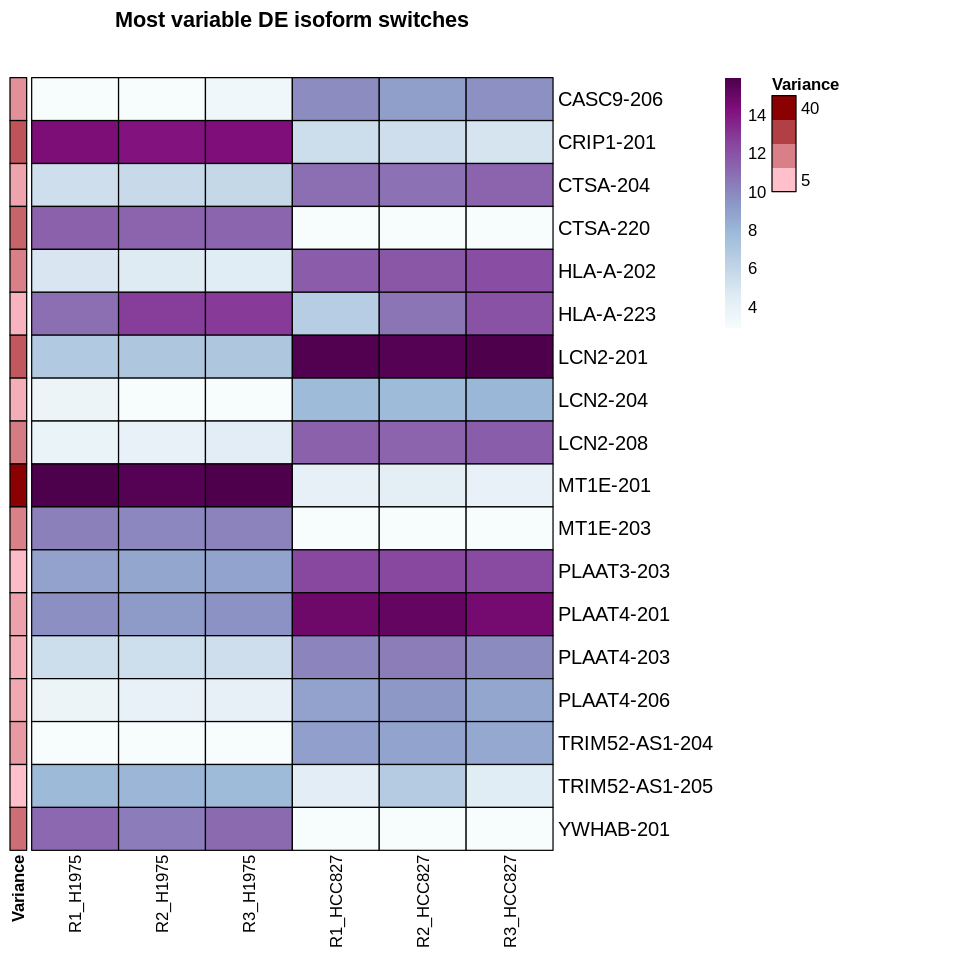

In [120]:
options(repr.plot.width = 8, repr.plot.height = 8)

# 1. Get the full matrix
valid_ids <- unique(tx_vst_data$feature_id)
heatmap_mat_all <- assay(tvsd)[valid_ids, ]

# --- Step 1: Filter by Expression (Remove Noise) ---
keep_expr <- rowMaxs(heatmap_mat_all) > 8
mat_filtered_expr <- heatmap_mat_all[keep_expr, ]

# --- Step 2: Filter by Variance (Focus on Switches) ---
row_vars_all <- rowVars(mat_filtered_expr)
names(row_vars_all) <- rownames(mat_filtered_expr)

n_top <- 20
top_indices <- order(row_vars_all, decreasing = TRUE)[1:min(n_top, nrow(mat_filtered_expr))]
variable_ids <- rownames(mat_filtered_expr)[top_indices]

# --- Step 3: Alphabetical Sort & Final Matrix ---
sorted_ids <- variable_ids[order(variable_ids)]
heatmap_mat <- heatmap_mat_all[sorted_ids, ]

# --- Step 4: Create Annotation & Define Colors ---
# 4a. Create the annotation data frame
row_ann <- data.frame(Variance = row_vars_all[sorted_ids])
rownames(row_ann) <- sorted_ids

# 4b. NEW: Define custom color palette for the annotation
# This creates a smooth gradient from white (low variance) to red (high variance)
ann_colors <- list(
  Variance = colorRampPalette(c("pink", "red4"))(300)
)

# --- Step 5: Generate and Save Plot ---
# Main heatmap colors (Blues)
heatmap_colors <- colorRampPalette(brewer.pal(n = 9, name = "BuPu"))(300)

pheatmap(
  heatmap_mat,
  annotation_row = row_ann,       # Add the bar
  annotation_colors = ann_colors, # Apply the custom red colors
  main = "Most variable DE isoform switches\n",
  color = heatmap_colors,
  border_color = "black",
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  show_rownames = TRUE,
  fontsize_row = 12,
  angle_col = 90,
  width = 10,  # Increased width for better spacing
  height = 8
)